# Sprawozdanie 2
### Piotr Kardyński Grupa 3

#### Wczytanie danych

Wczytanie danych z linku [Repozytorium UCI](https://archive.ics.uci.edu/dataset/45/heart+disease) lub z lokalnego pliku [heart.csv](heart.csv), (*dodany ze strony interentowj [archive-beta](https://archive-beta.ics.uci.edu/dataset/45/heart+disease) z powodu nie działajacego wczesniej Repozytorium UCI, jesli jednak zadaziała to zabaczymy to w "Data source"*)

In [1]:
import func 
import knn 
import charts 
import decision_tree


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.tree import plot_tree

df, source = func.load_heart_data()
func.dataset_summary(df, source)

Attempting to fetch data from UCI via ID 45...

DATASET SUMMARY
Data source    : UCI Repository API (ID 45)
Number of rows : 303
Number of columns : 14


#### Sprawdzenie ułorzenia danych w zbiorze

In [2]:
func.dataset_overview(df)


DATASET OVERVIEW (First 5 rows)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  target  
0  0.0   6.0       0  
1  3.0   3.0       2  
2  2.0   7.0       1  
3  0.0   3.0       0  
4  0.0   3.0       0  


O czym "mówią" te dane:
* Dane ciągłe (liczbowe): np. age (wiek), trestbps (ciśnienie), chol (cholesterol), thalach (tętno). Mają szeroki zakres wartości
* Dane kategoryczne (zakodowane jako liczby): np. sex (1 = mężczyzna; 0 = kobieta), cp (typ bólu: 1, 2, 3, 4), fbs (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false)
* Dane zmiennoprzecinkowe: oldpeak (np. 2.3) oraz ca (np. 0.0)

Pierwsze obseracje:
* Pacjent nr 0: Mężczyzna (sex=1), 63 lata, wysokie ciśnienie (145), cholesterol (233) zdrowy (target=0)
* Pacjent nr 1: Mężczyzna, 67 lat, bardzo wysokie ciśnienie (160) i cholesterol (286), chory (target=2)
te dane pokazują bardzo duża róznorodność.

Problem z kolumną *target*:
* W dokumentacji UCI: 0 = brak choroby, 1-4 = stopnie choroby serca.
* Zadaniem jest klasyfikacja (chory vs zdrowy) wiec trzeba tą kolumnę zmienic na system binarny gdzie: 
    *target* = 0 -> 0
    *target* > 0 -> 1

#### Analiza zbioru

Sprawdzenie:
* rozkładu zmiennych
* liczebności
* liczby brakujących danych w zbiorze

In [3]:
func.dataset_check_categorical_health(df)
func.dataset_variable_distribution(df)
func.dataset_missing_values_analysis(df)


CATEGORICAL COLUMN ANALYSIS
Column: sex        | Absence (NaN):  0 | Unique values: [1 0]
Column: cp         | Absence (NaN):  0 | Unique values: [1 4 3 2]
Column: fbs        | Absence (NaN):  0 | Unique values: [1 0]
Column: restecg    | Absence (NaN):  0 | Unique values: [2 0 1]
Column: exang      | Absence (NaN):  0 | Unique values: [0 1]
Column: slope      | Absence (NaN):  0 | Unique values: [3 2 1]
Column: ca         | Absence (NaN):  4 | Unique values: [ 0.  3.  2.  1. nan]
Column: thal       | Absence (NaN):  2 | Unique values: [ 6.  3.  7. nan]

VARIABLE DISTRIBUTION (Target)
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

MISSING VALUES ANALYSIS
ca      4
thal    2
dtype: int64


CATEGORICAL COLUMN ANALYSIS:
* potwierdzenie braku danych; *ca* brakuje 4 warości, w *thal* brakuje 2 -> istnieje 6 wierszy z brakami trzba je uzupełnic lub usunąć wiersze przed trenowaniem drzewa
* Większość kolumn kategorycznych (sex, cp, fbs, restecg, exang, slope) nie posiada braków danych i zawiera poprawne klasy.
* Dane są zakodowane numerycznie, ale mają charakter jakościowy, co sprzyja wykorzystaniu modelu drzewa decyzyjnego

VARIABLE DISTRIBUTION (Target):
* 164 osoby -> pacjenci zdrowi
* reszta(139) -> chorzy (1–4 stopień zaawansowania według zwężenia naczyń krwionośnych)

MISSING VALUES ANALYSIS:
* potwierdza sie wczesniejszy wniosek *ca* i *thal* posiadają braki
* ten zbiór ma 303 wiersze więc: 6/303=0,01980 -> braki to mniej niż 2% zbioru


#### Wiersze z NaN:

In [4]:
func.dataset_show_rows_with_nan(df)


ROWS WITH MISSING VALUES (NaN)
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
87    53    0   3       128   216    0        2      115      0      0.0   
166   52    1   3       138   223    0        0      169      0      0.0   
192   43    1   4       132   247    1        2      143      1      0.1   
266   52    1   4       128   204    1        0      156      1      1.0   
287   58    1   2       125   220    0        0      144      0      0.4   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  target  
87       1  0.0   NaN       0  
166      1  NaN   3.0       0  
192      2  NaN   7.0       1  
266      2  0.0   NaN       2  
287      2  NaN   7.0       0  
302      1  NaN   3.0       0  


#### Jak "załatać" wartości:
Jest kilka mozliwości:
* moda - jest niestety „ślepa” – wstawia każdemu to samo, nie patrząc na to, kim jest pacjent.
* średnia - w kolumnie thal wartości to 3, 6, 7. Policzna średnia, mogłaby wyjść np. 4.5. W medycynie nie istnieje wynik testu talasemii "4.5" tylko thal: 3 = normal; 6 = fixed defect; 7 = reversable defect.
* algorytm K-Nearest Neighbors (k-NN) Imputer „powolnego sąsiada” - Zamiast wstawiać najczęstszą wartość z całego zbioru, algorytm szuka k pacjentów najbardziej podobnych do tego z brakiem danych (np. w tym samym wieku, z podobnym cholesterolem i ciśnieniem).

Z powyższych algorytmów i metod najlepiej wybrać knn


In [5]:
df_clean = knn.impute_knn_data(df)
knn.show_imputed_values(df, df_clean)

print("Braki po k-NN:")
print(df_clean.isnull().sum().sum())


VERIFYING IMPUTED VALUES (KNN)
Values inserted by KNN in the missing places:
     slope   ca  thal  target
87     1.0  0.0   6.0     0.0
166    1.0  1.0   3.0     0.0
192    2.0  1.0   7.0     1.0
266    2.0  0.0   3.0     2.0
287    2.0  2.0   7.0     0.0
302    1.0  0.0   3.0     0.0
Braki po k-NN:
0


Widać ze po procesie knn ze wzgledu na obliczenia matematyczne stosowane przez ten algorytm liczby całkowite zmieniły sie na liczby zmiennoprzeciknkowe. Nie jest to problem poniewaz w dalejsze czesci zadania drzewo decyzyjne bez problemu zrozumie, że np 1.0 to to samo co 1

#### Poprawa danych target:

Należy zamienić wszystkie wartości *target* wieksze od 0 na 1 ponieważ jak wcześciej ustalono; zdrowy: *target* = 0 -> 0, chory: *target* > 0 -> 1

In [6]:
print("\n Before")
func.dataset_overview(df_clean)
print("\nAfter: healthy: target = 0 -> 0, sick: target > 0 -> 1")
df_clean['target'] = np.where(df_clean['target'] > 0, 1, 0)
func.dataset_overview(df_clean)


 Before

DATASET OVERVIEW (First 5 rows)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0     0.0  
1    2.0  3.0   3.0     2.0  
2    2.0  2.0   7.0     1.0  
3    3.0  0.0   3.0     0.0  
4    1.0  0.0   3.0     0.0  

After: healthy: target = 0 -> 0, sick: target > 0 -> 1

DATASET OVERVIEW (First 5 rows)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.

#### Sprawdzenie które kolumny najbardziej mowią o chorobie


Stworzenie wykresów które pokażą każda kolumne według *target*

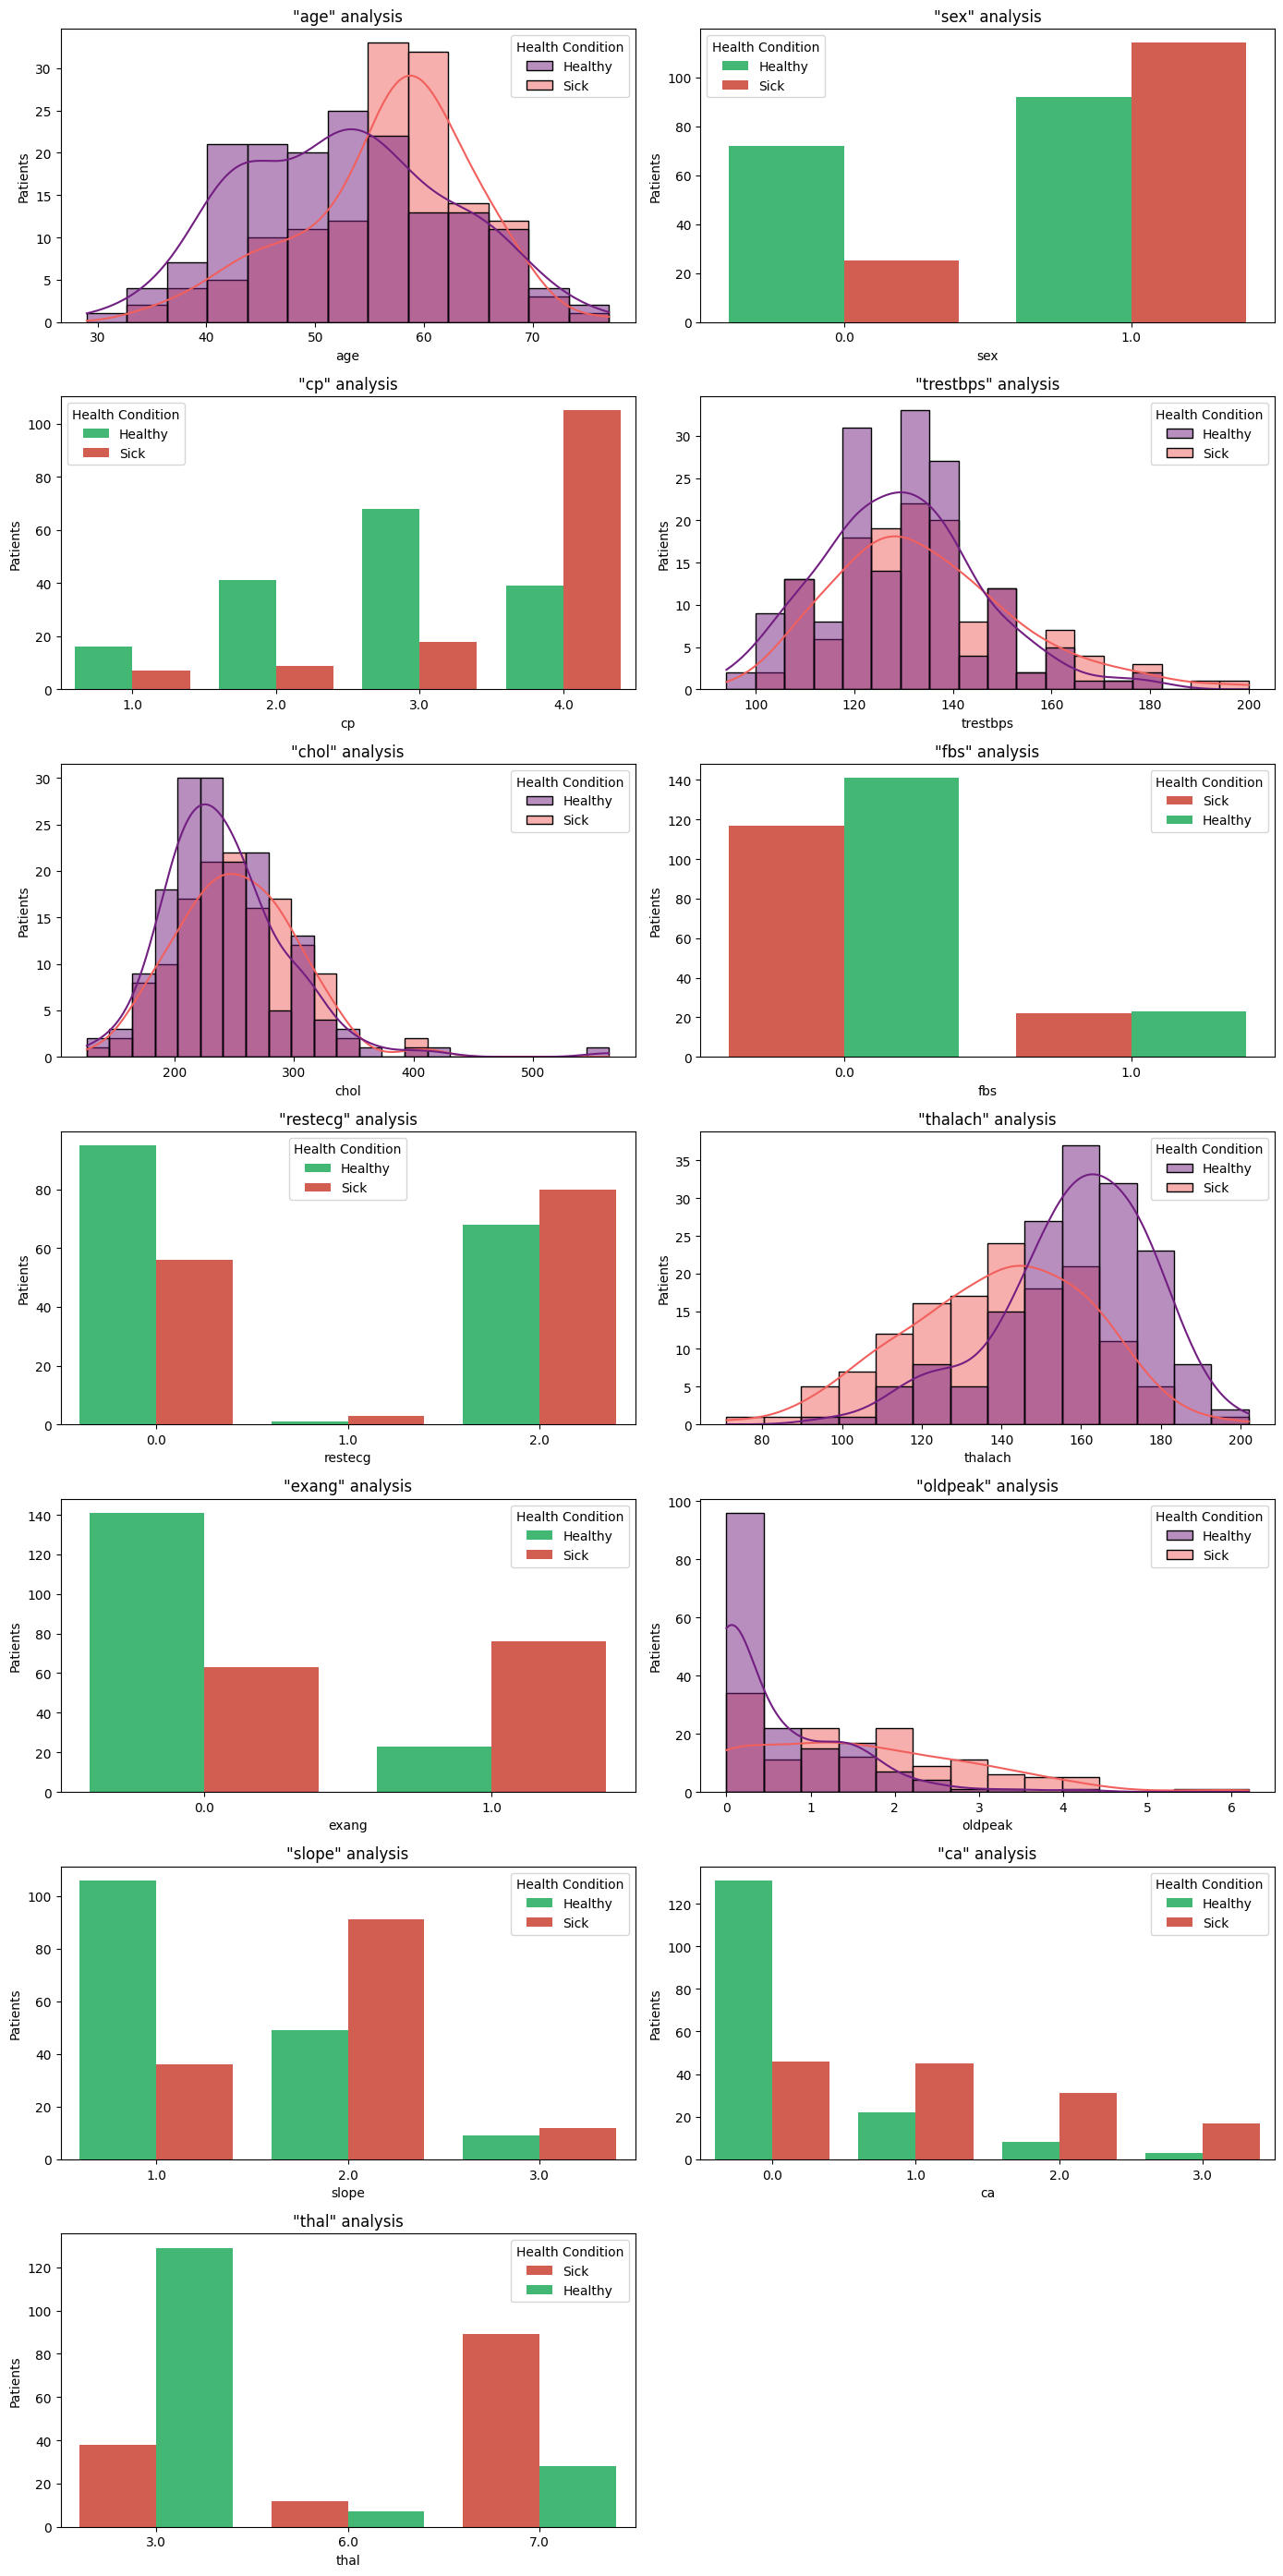

In [7]:
# list of all features (without the target column)
features = [col for col in df_clean.columns if col != 'target']

# number of columns in the grid, and calculate the number of rows
cols_in_grid = 2
rows_in_grid = (len(features) + 1) // cols_in_grid

# Big fig with charts
plt.figure(figsize=(14, 4 * rows_in_grid))

for i, col in enumerate(features):
    # next space for another chart
    plt.subplot(rows_in_grid, cols_in_grid, i + 1)
    
    
    charts.plot_feature_vs_target(df_clean, col)


plt.tight_layout()
plt.show()

Najsilniejsze wskaźniki
* cp - kategoria 4.0. Tam słupek "Sick" drastycznie dominuje nad "Healthy". To sugeruje, że ten typ bólu jest bardzo silnym indykatorem choroby
* thal - 3.0 mnóstwo zdrowych osób, przy wartości 7.0 sytuacja się odwraca, a pomiedzy tymi wartościami prawie nikogo nie ma
* age - ryzyko rośnie z wiekiem
* sex - mężczyźni chorują wiecej
* ca - im mniejsza wartość tym wiecej zdrowych w stosunku do chorych, 0.0 prawie sami zdrowi, 3.0 prawie sami chorzy
* exang - osoby 1.0 są znacznie częściej w grupie sick


In [8]:
X_train, X_test, y_train, y_test = decision_tree.split_dateset(df_clean, 0.2)


=== DATA BREAKDOWN SUMMARY ===
Entire collection: 303 
Training set: 242 
Test set (for model testing): 61 

Checking class balance (stratify):
Proportion sick patients in the training set: 45.9%
Proportion sick patients in the test set: 45.9%


#### Stworzenie kilku drzew, porównianie wyników

* drzewo bez limitu gałęzi

--- Training Model (max_depth=Unlimited) ---
Model Accuracy: 70.49%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.74      0.70      0.72        33
        Sick       0.67      0.71      0.69        28

    accuracy                           0.70        61
   macro avg       0.70      0.71      0.70        61
weighted avg       0.71      0.70      0.71        61



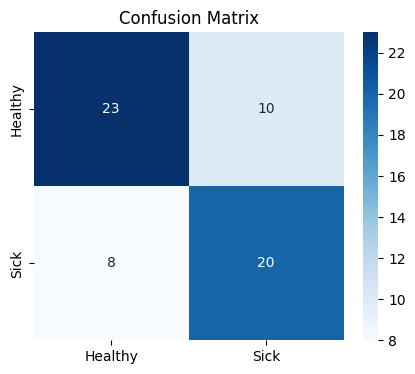

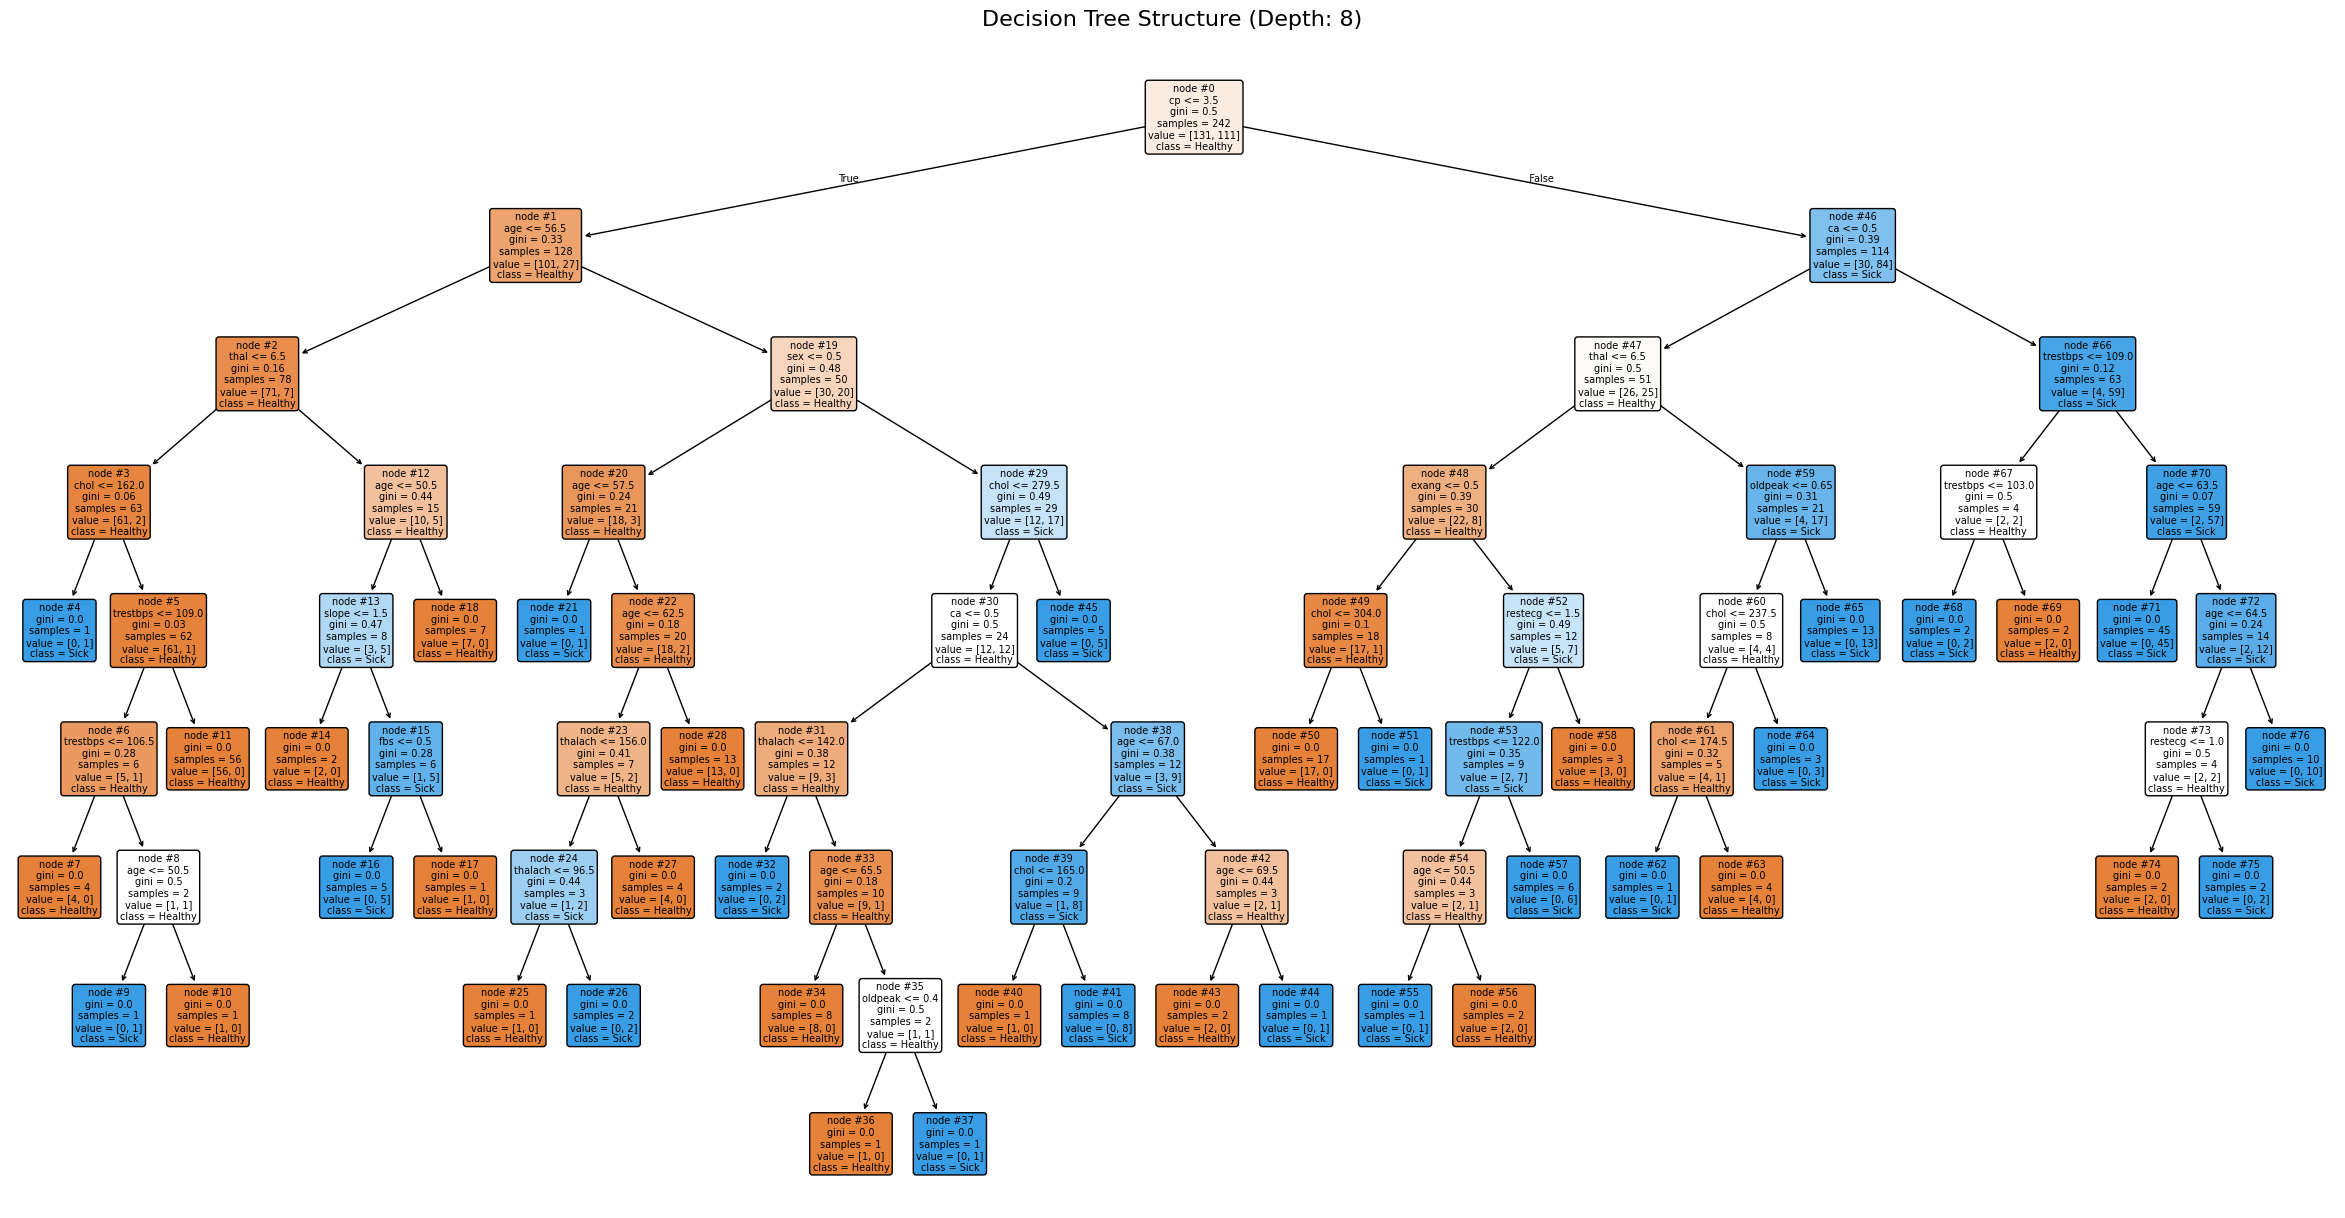

c:\Users\Piotrek\Desktop\projekt_programowanie\Task_2\charts.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


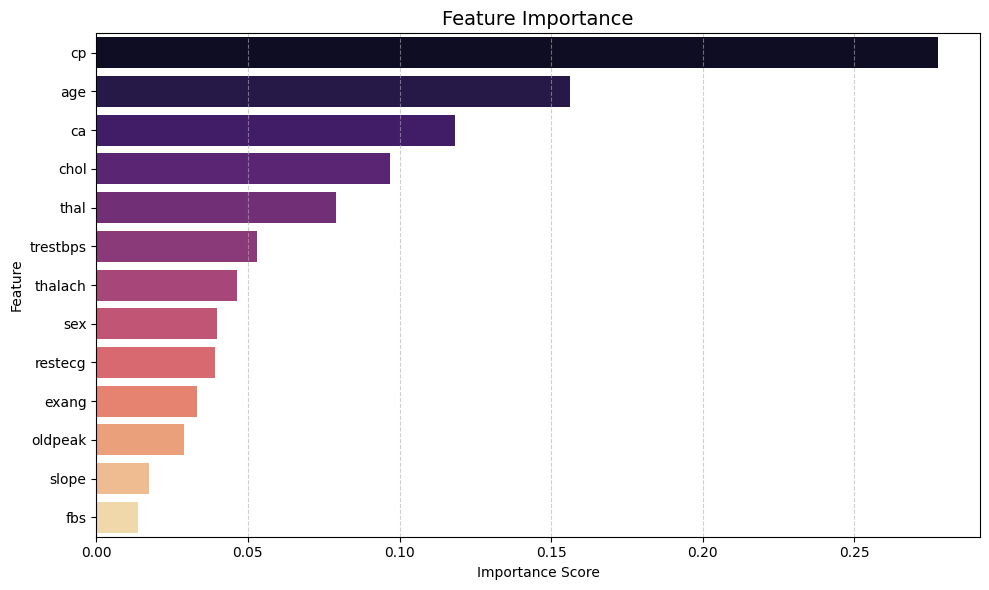

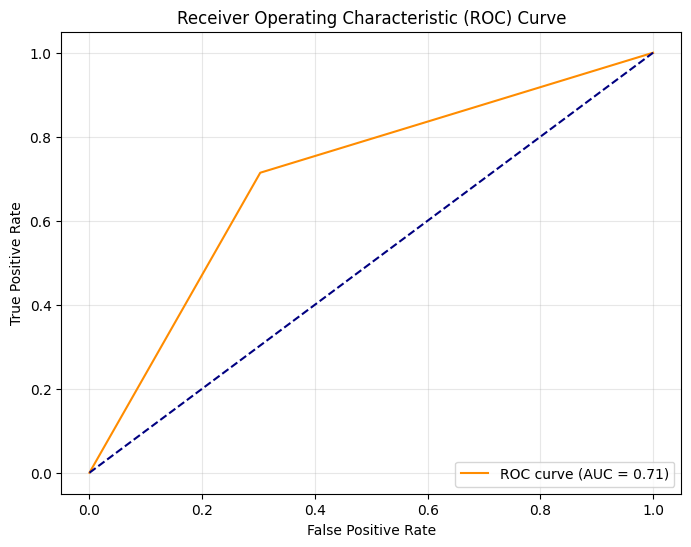

In [9]:
my_tree, y_pred = decision_tree.run_tree_analysis(X_train, X_test, y_train, y_test)


charts.plot_confusion_matrix(y_test, y_pred)
charts.plot_tree_structure(my_tree, X_train.columns)
charts.plot_feature_importance(my_tree, X_train.columns)
charts.plot_roc_curve(my_tree, X_test, y_test)

* drzewa z limitem gałęzi

--- Training Model (max_depth=3) ---
Model Accuracy: 78.69%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.81      0.79      0.80        33
        Sick       0.76      0.79      0.77        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



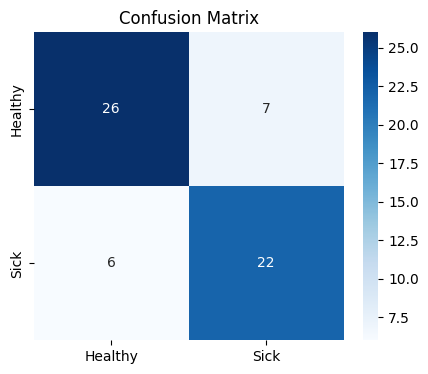

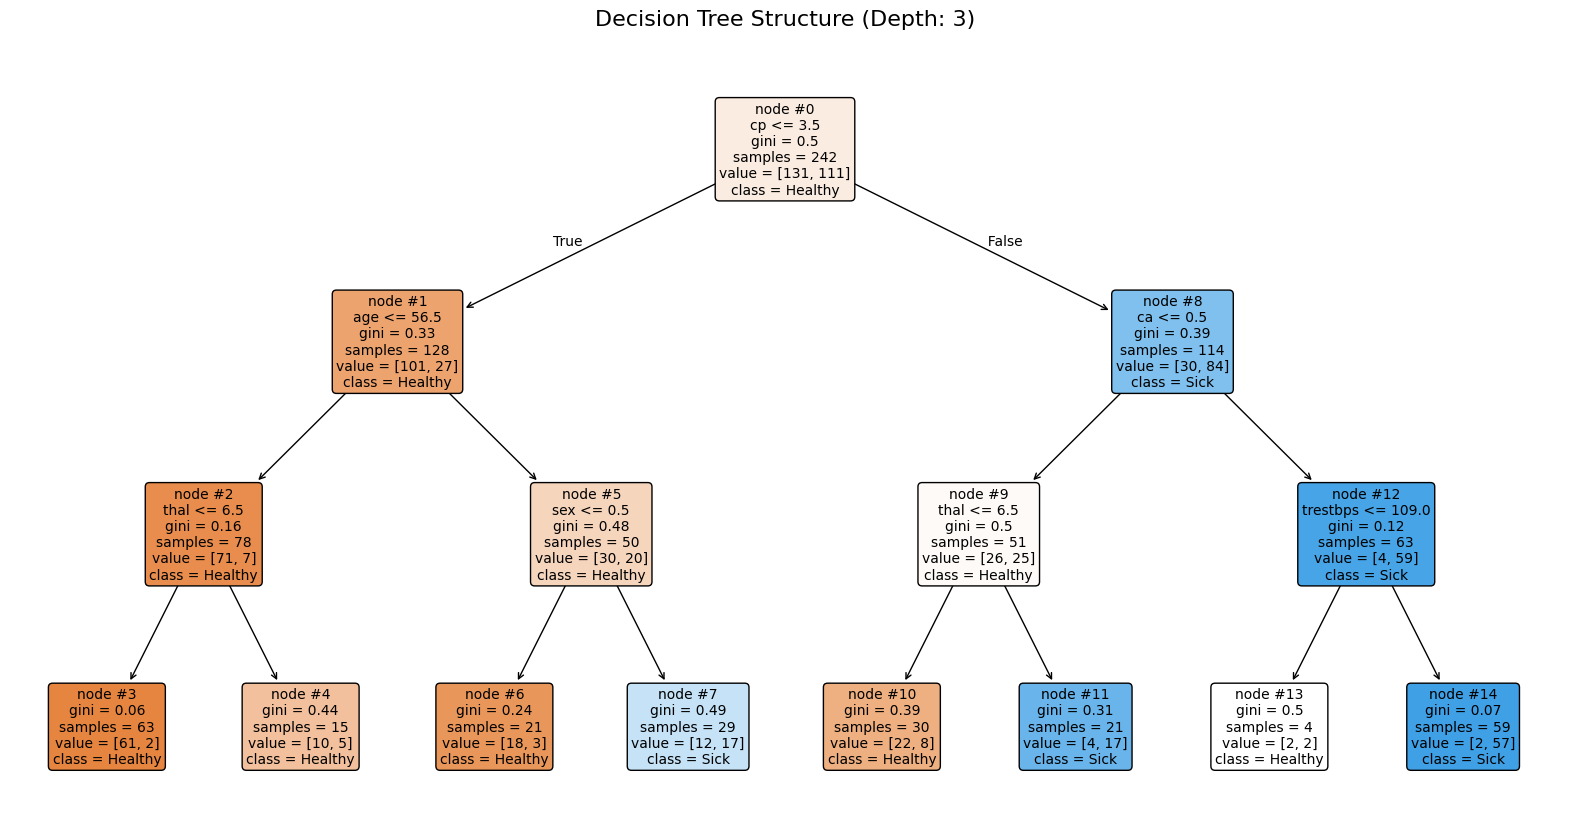

c:\Users\Piotrek\Desktop\projekt_programowanie\Task_2\charts.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


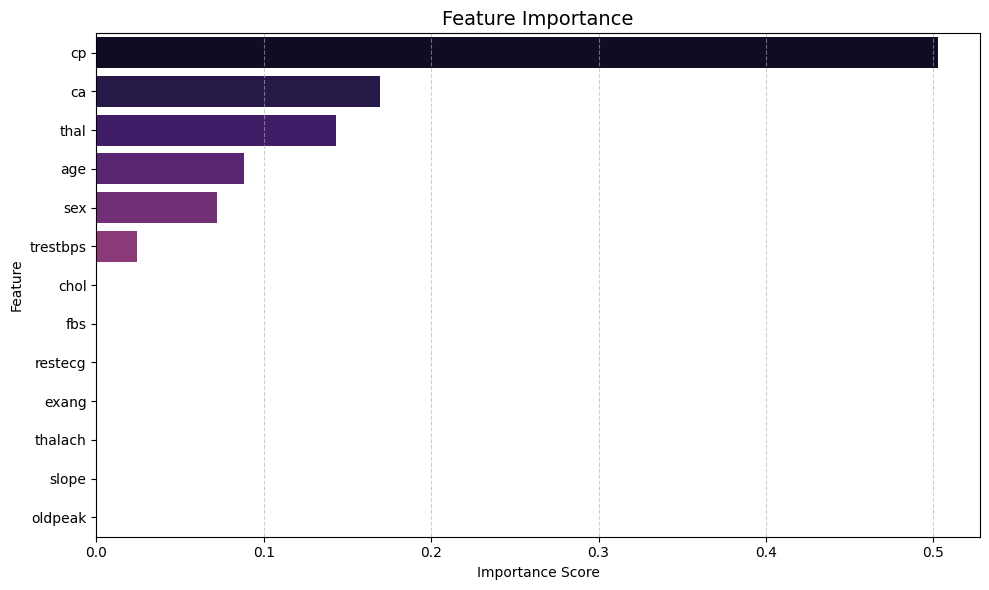

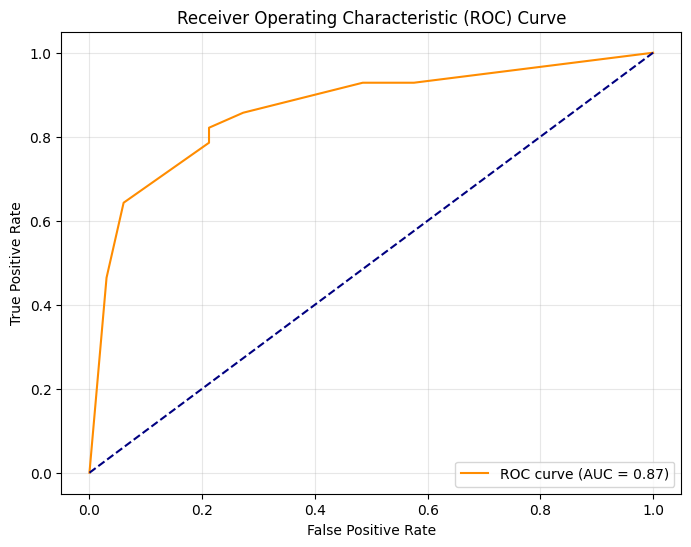

In [10]:
my_tree, y_pred = decision_tree.run_tree_analysis(X_train, X_test, y_train, y_test, max_depth=3)


charts.plot_confusion_matrix(y_test, y_pred)
charts.plot_tree_structure(my_tree, X_train.columns)
charts.plot_feature_importance(my_tree, X_train.columns)
charts.plot_roc_curve(my_tree, X_test, y_test)

--- Training Model (max_depth=4) ---
Model Accuracy: 72.13%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.72      0.79      0.75        33
        Sick       0.72      0.64      0.68        28

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61



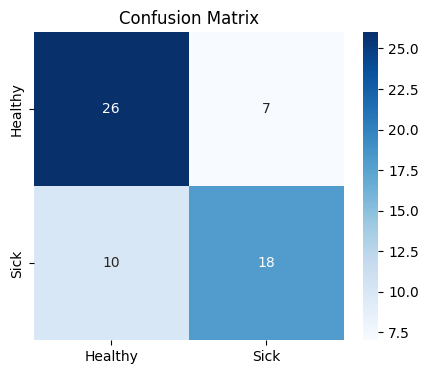

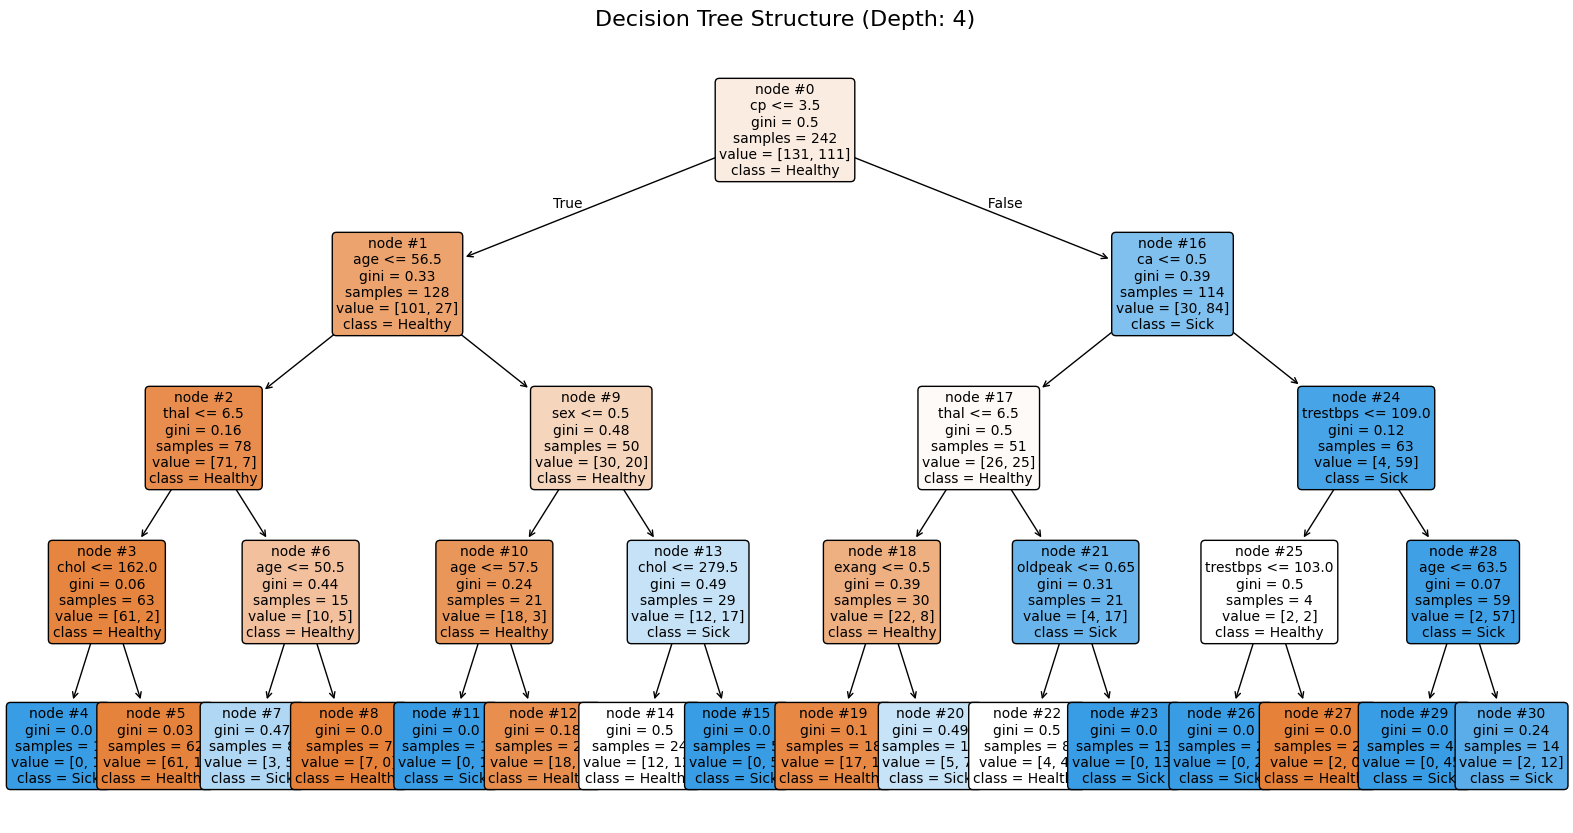

c:\Users\Piotrek\Desktop\projekt_programowanie\Task_2\charts.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


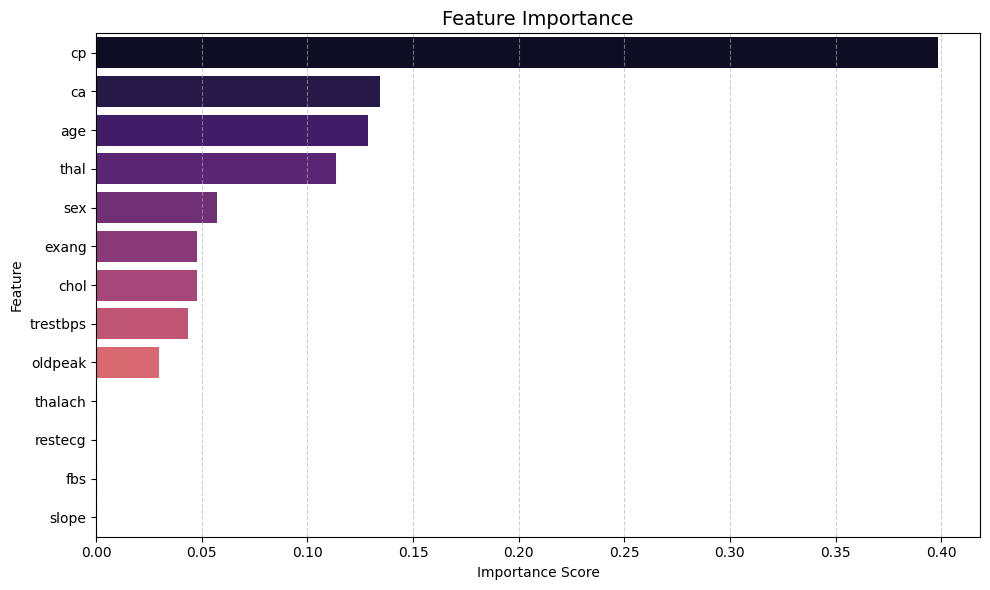

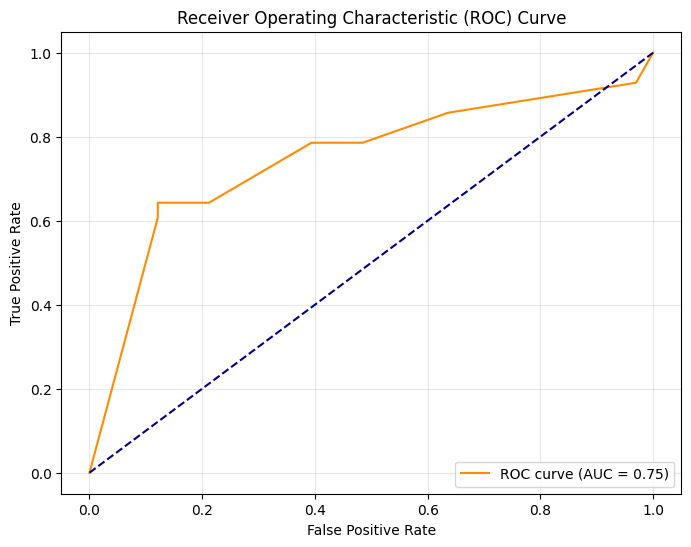

In [11]:
my_tree, y_pred = decision_tree.run_tree_analysis(X_train, X_test, y_train, y_test, max_depth=4)


charts.plot_confusion_matrix(y_test, y_pred)
charts.plot_tree_structure(my_tree, X_train.columns)
charts.plot_feature_importance(my_tree, X_train.columns)
charts.plot_roc_curve(my_tree, X_test, y_test)

--- Training Model (max_depth=5) ---
Model Accuracy: 70.49%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.73      0.73      0.73        33
        Sick       0.68      0.68      0.68        28

    accuracy                           0.70        61
   macro avg       0.70      0.70      0.70        61
weighted avg       0.70      0.70      0.70        61



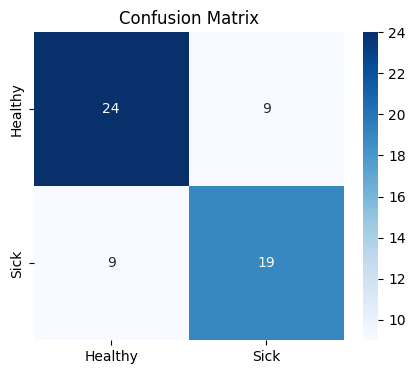

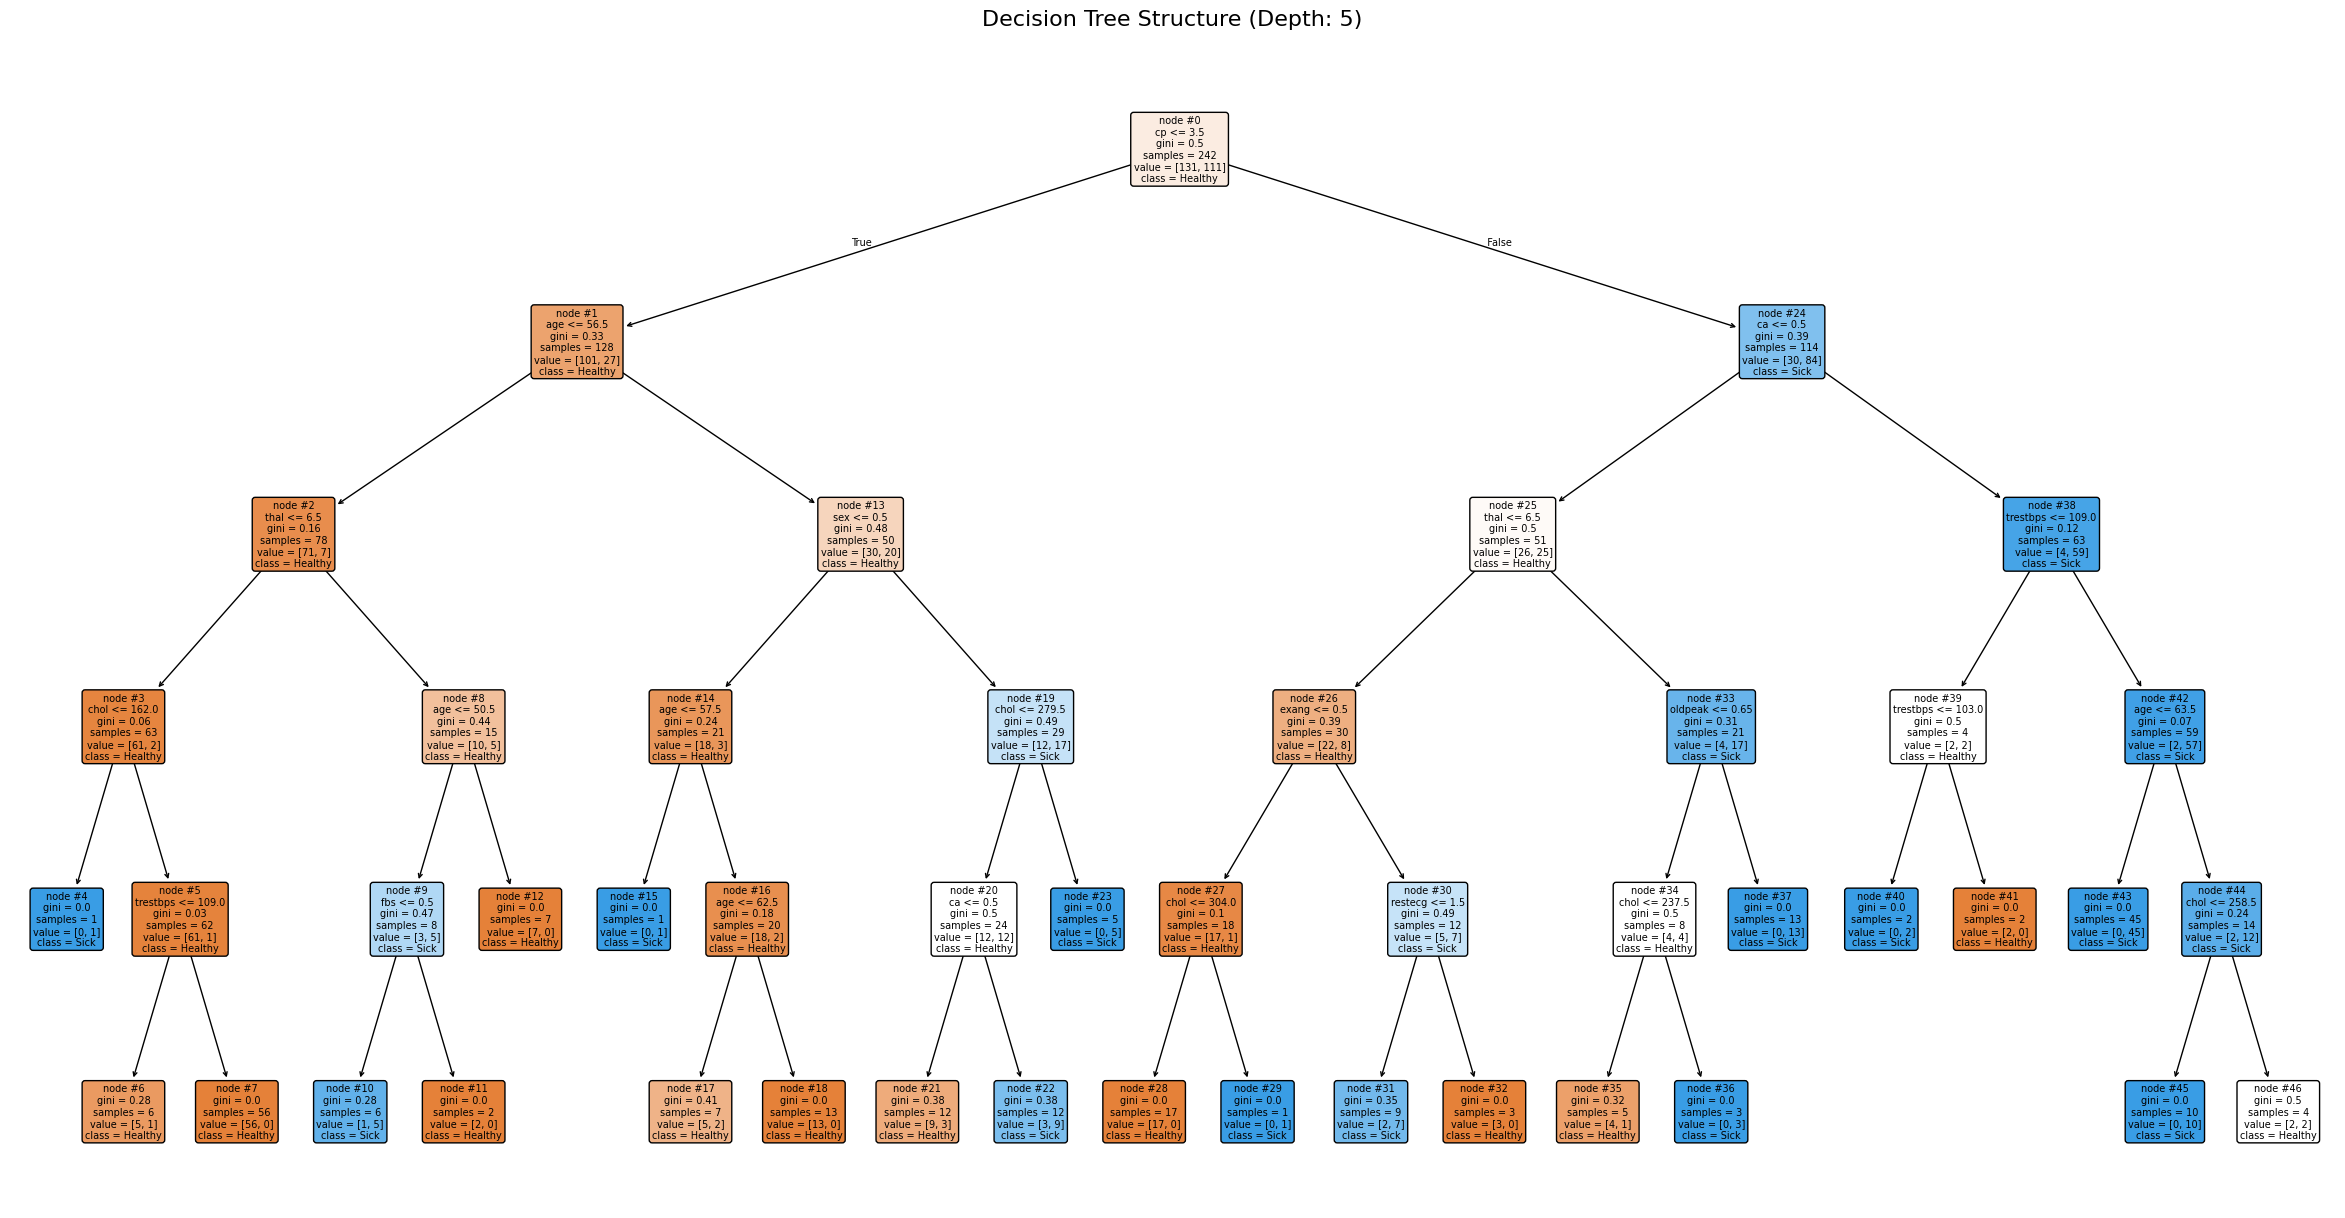

c:\Users\Piotrek\Desktop\projekt_programowanie\Task_2\charts.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


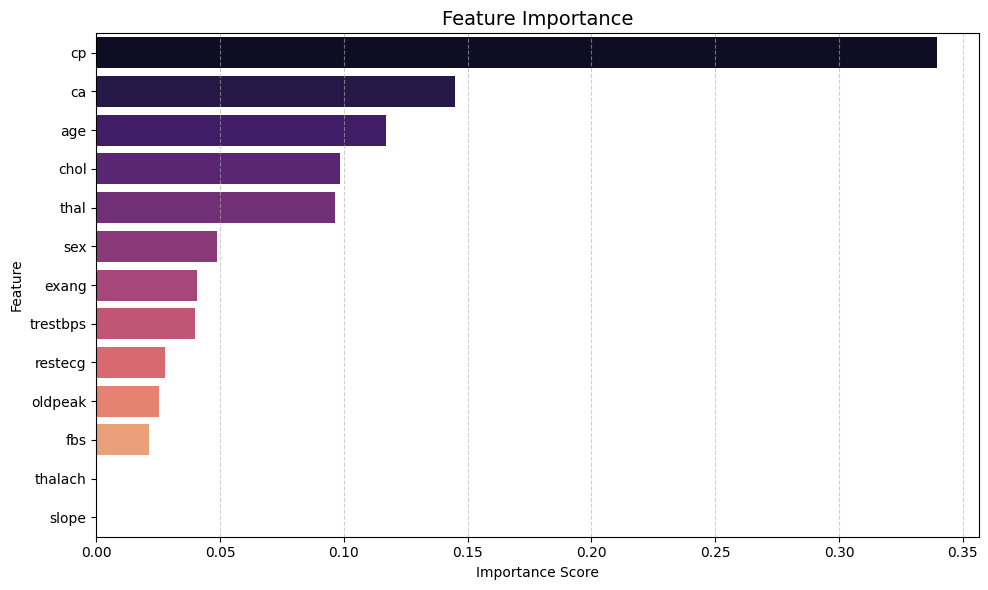

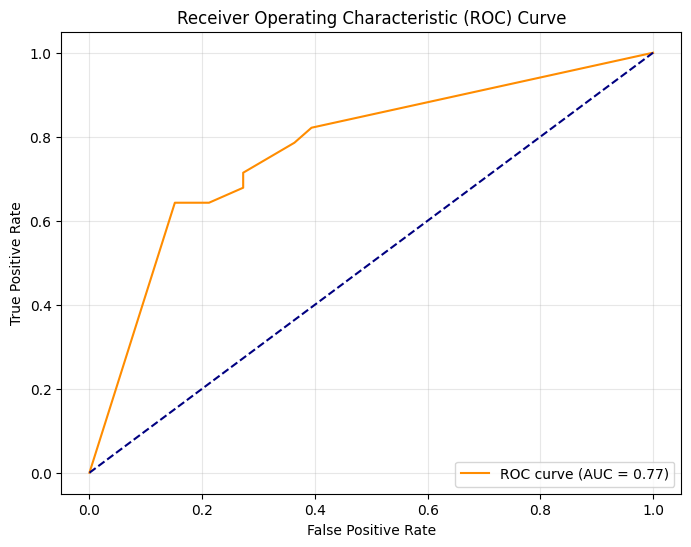

In [12]:
my_tree, y_pred = decision_tree.run_tree_analysis(X_train, X_test, y_train, y_test, max_depth=5)


charts.plot_confusion_matrix(y_test, y_pred)
charts.plot_tree_structure(my_tree, X_train.columns)
charts.plot_feature_importance(my_tree, X_train.columns)
charts.plot_roc_curve(my_tree, X_test, y_test)

--- Training Model (max_depth=6) ---
Model Accuracy: 70.49%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.74      0.70      0.72        33
        Sick       0.67      0.71      0.69        28

    accuracy                           0.70        61
   macro avg       0.70      0.71      0.70        61
weighted avg       0.71      0.70      0.71        61



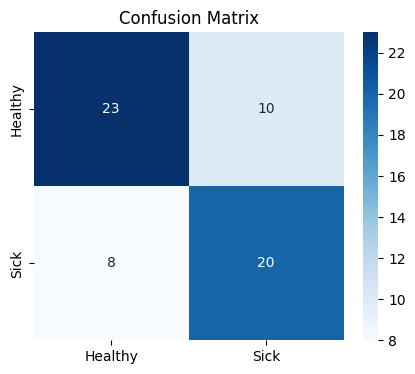

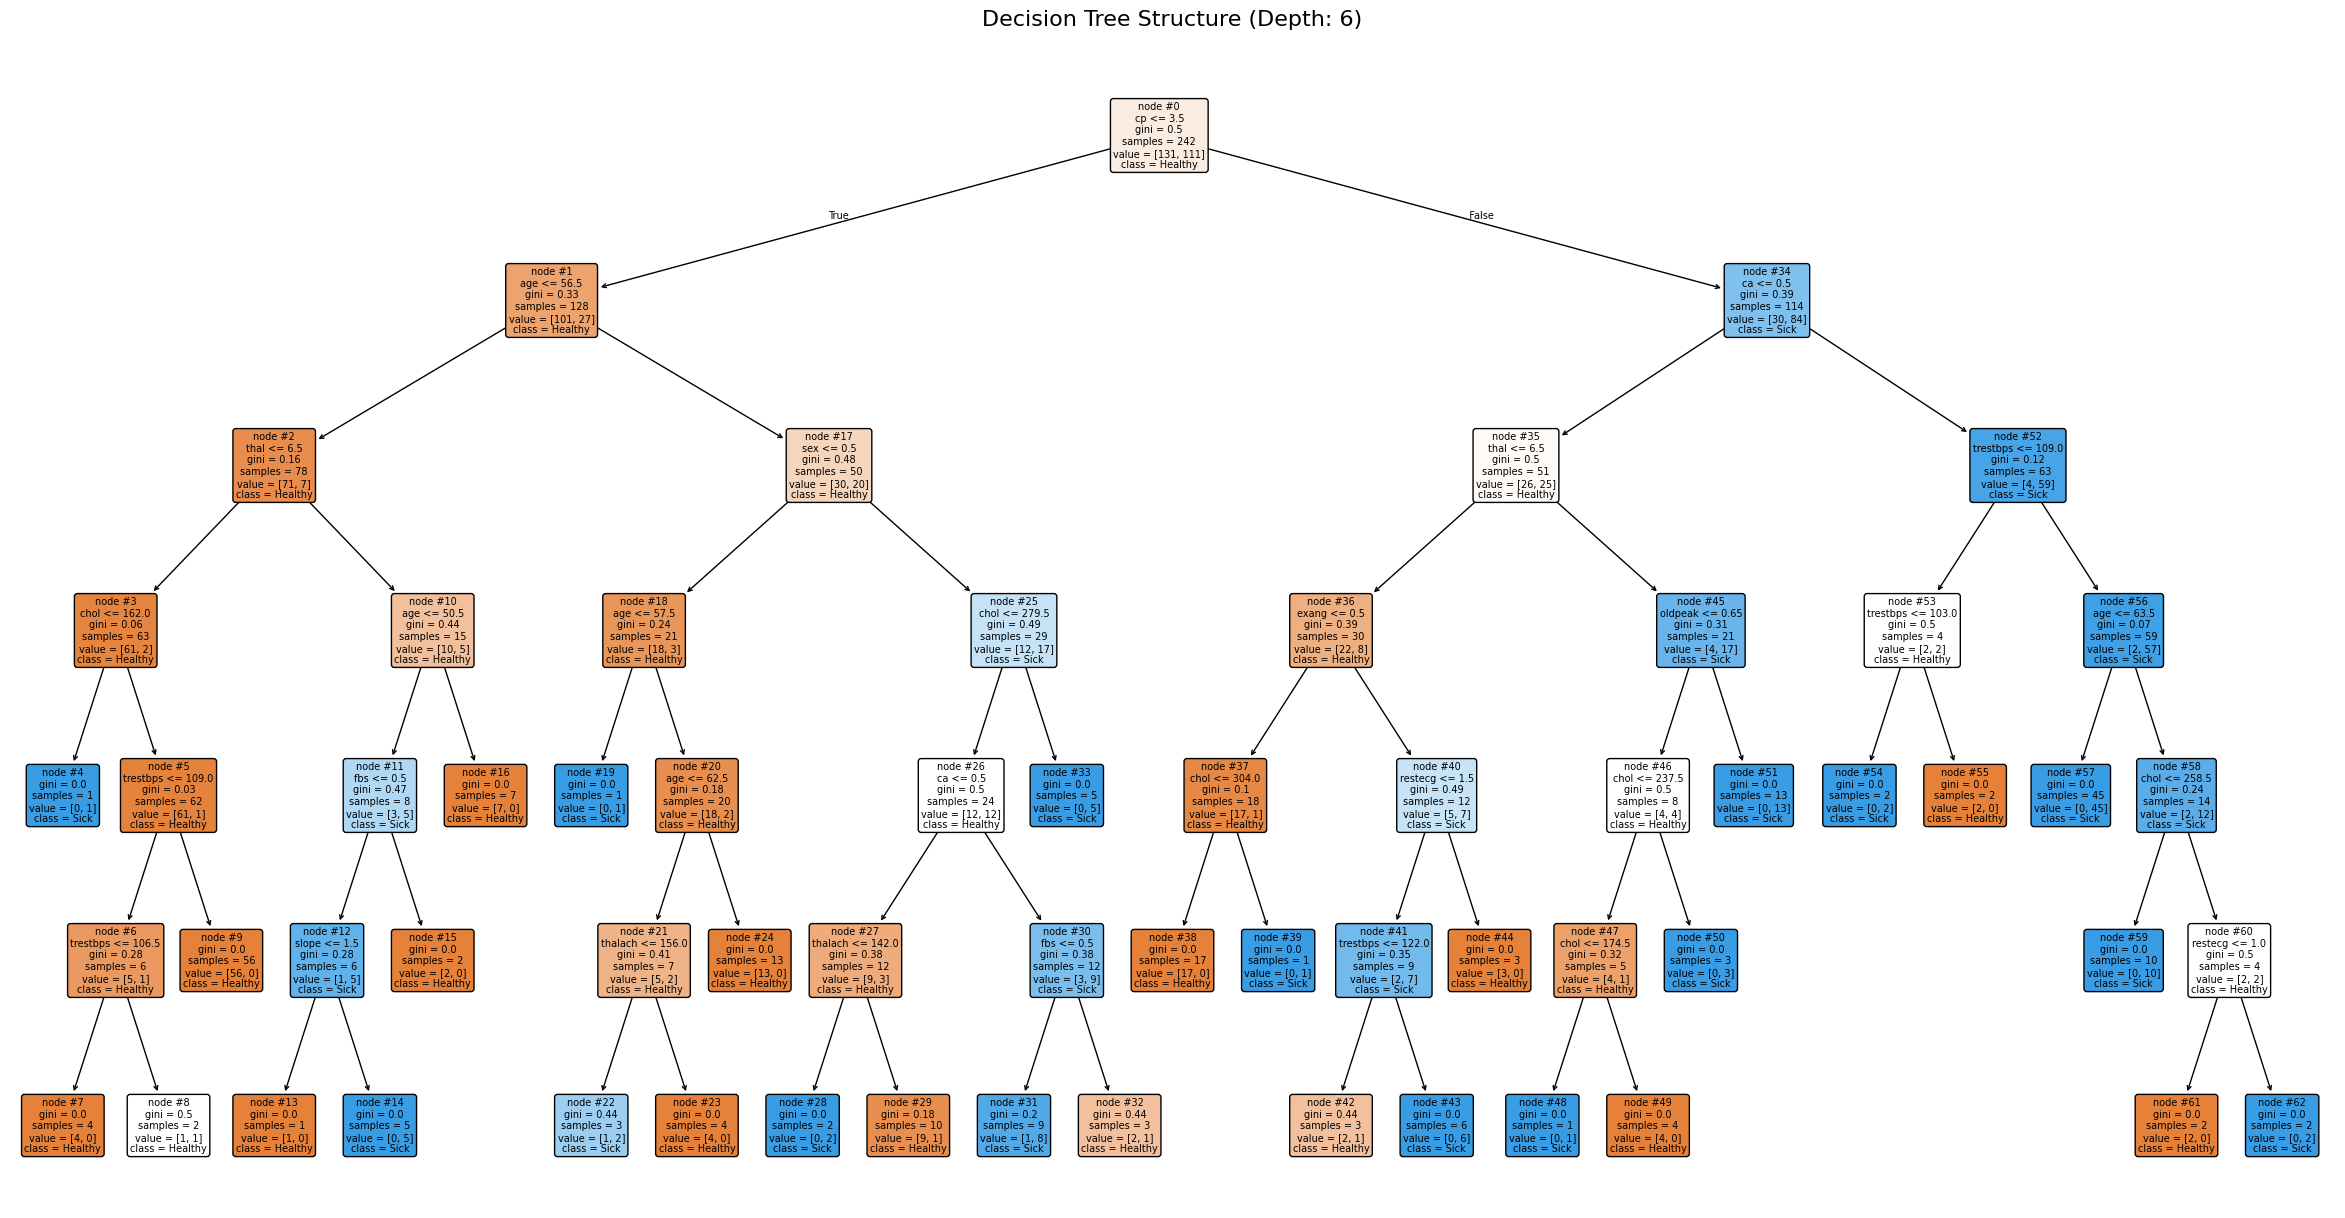

c:\Users\Piotrek\Desktop\projekt_programowanie\Task_2\charts.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


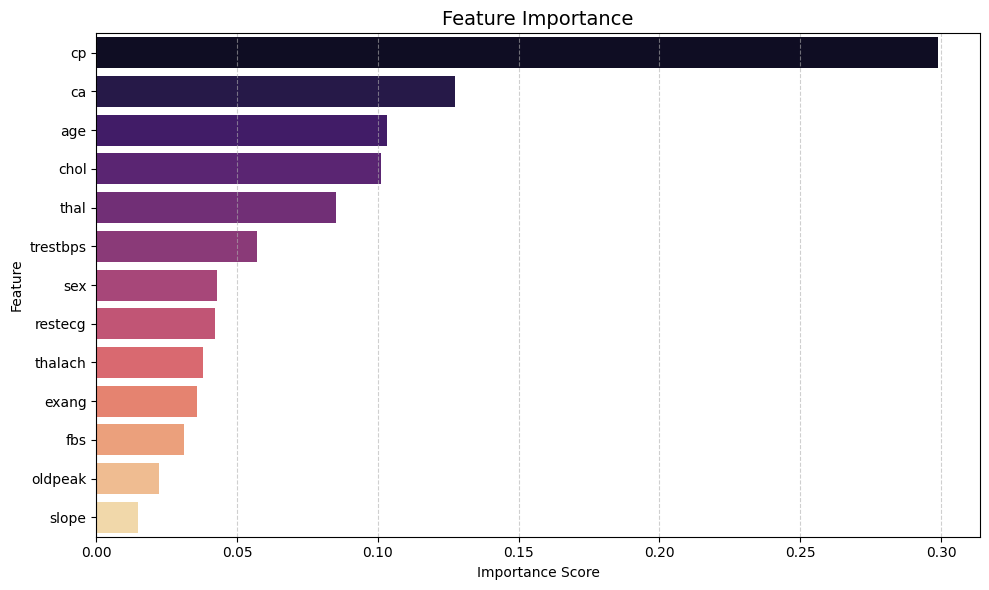

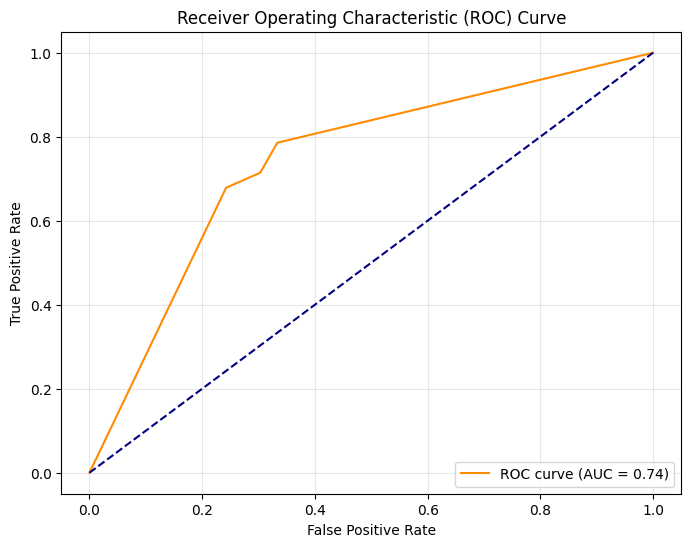

In [13]:
my_tree, y_pred = decision_tree.run_tree_analysis(X_train, X_test, y_train, y_test, max_depth=6)


charts.plot_confusion_matrix(y_test, y_pred)
charts.plot_tree_structure(my_tree, X_train.columns)
charts.plot_feature_importance(my_tree, X_train.columns)
charts.plot_roc_curve(my_tree, X_test, y_test)

#### Wnioski

Zestawienie najważniejszych wyników:

Unlimited depth(8):

Model Accuracy: 70.49%

|  | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **Healthy** | 0.74 | 0.70 | 0.72 | 33 |
| **Sick** | 0.67 | 0.71 | 0.69 | 28 |
| | | | | |
| **Accuracy** | | | **0.70** | 61 |
| **Macro Avg** | 0.70 | 0.71 | 0.70 | 61 |
| **Weighted Avg** | 0.71 | 0.70 | 0.71 | 61 |

**Dodatkowe wskaźniki:**
* **ROC AUC Score:** 0.71

Depth 3:

Model Accuracy: 78.69%

|  | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **Healthy** | 0.81 | 0.79 | 0.80 | 33 |
| **Sick** | 0.76 | 0.79 | 0.77 | 28 |
| | | | | |
| **Accuracy** | | | **0.79** | 61 |
| **Macro Avg** | 0.79 | 0.79 | 0.79 | 61 |
| **Weighted Avg** | 0.79 | 0.79 | 0.79 | 61 |

**Dodatkowe wskaźniki:**
* **ROC AUC Score:** **0.87**





Depth 4:

Model Accuracy: 72.13%

|  | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **Healthy** | 0.72 | 0.79 | 0.75 | 33 |
| **Sick** | 0.72 | 0.64 | 0.68 | 28 |
| | | | | |
| **Accuracy** | | | **0.72** | 61 |
| **Macro Avg** | 0.72 | 0.72 | 0.72 | 61 |
| **Weighted Avg** | 0.72 | 0.72 | 0.72 | 61 |

**Dodatkowe wskaźniki:**
* **ROC AUC Score:** 0.75




Depth 5:

Model Accuracy: 70.49%


|  | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **Healthy** | 0.73 | 0.73 | 0.73 | 33 |
| **Sick** | 0.68 | 0.68 | 0.68 | 28 |
| | | | | |
| **Accuracy** | | | **0.70** | 61 |
| **Macro Avg** | 0.70 | 0.70 | 0.70 | 61 |
| **Weighted Avg** | 0.70 | 0.70 | 0.70 | 61 |

**Dodatkowe wskaźniki:**
* **ROC AUC Score:** 0.77


Depth 6:

Model Accuracy: 70.49%


| Klasa / Metryka | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **Healthy** | 0.74 | 0.70 | 0.72 | 33 |
| **Sick** | 0.67 | 0.71 | 0.69 | 28 |
| | | | | |
| **Accuracy** | | | **0.70** | 61 |
| **Macro Avg** | 0.70 | 0.71 | 0.70 | 61 |
| **Weighted Avg** | 0.71 | 0.70 | 0.71 | 61 |

**Dodatkowe wskaźniki:**
* **ROC AUC Score:** 0.74


Poprzednie wyniki mówią, że więcej nie znaczy lepiej. Najpierw dokładność rośnie (model uczy się ogólnych zasad), następnie osiąga punkt optymalny ( dla tego zbioru max_depth=3). Potem zaczyna spadać. To jest moment, w którym drzewo staje się zbyt skomplikowane (zasada typu *"Jeśli pacjent ma wysoki cholesterol, ból klatki, ma na imię Jan i był na badaniu w czwartek o 14:00, to jest chory."*), możliwe że model ten bedzie miał tak dobre wyniki tylko dla tego zbioru testowego a dla innych już nie.

#### Sprawdzenie czy depth 3 jest też dobre na innym zbiorze

=== DATA BREAKDOWN SUMMARY ===
Entire collection: 303 
Training set: 242 
Test set (for model testing): 61 

Checking class balance (stratify):
Proportion sick patients in the training set: 45.9%
Proportion sick patients in the test set: 45.9%
--- Training Model (max_depth=3) ---
Model Accuracy: 80.33%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.82      0.82      0.82        33
        Sick       0.79      0.79      0.79        28

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



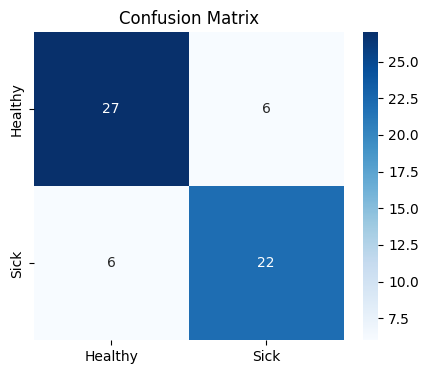

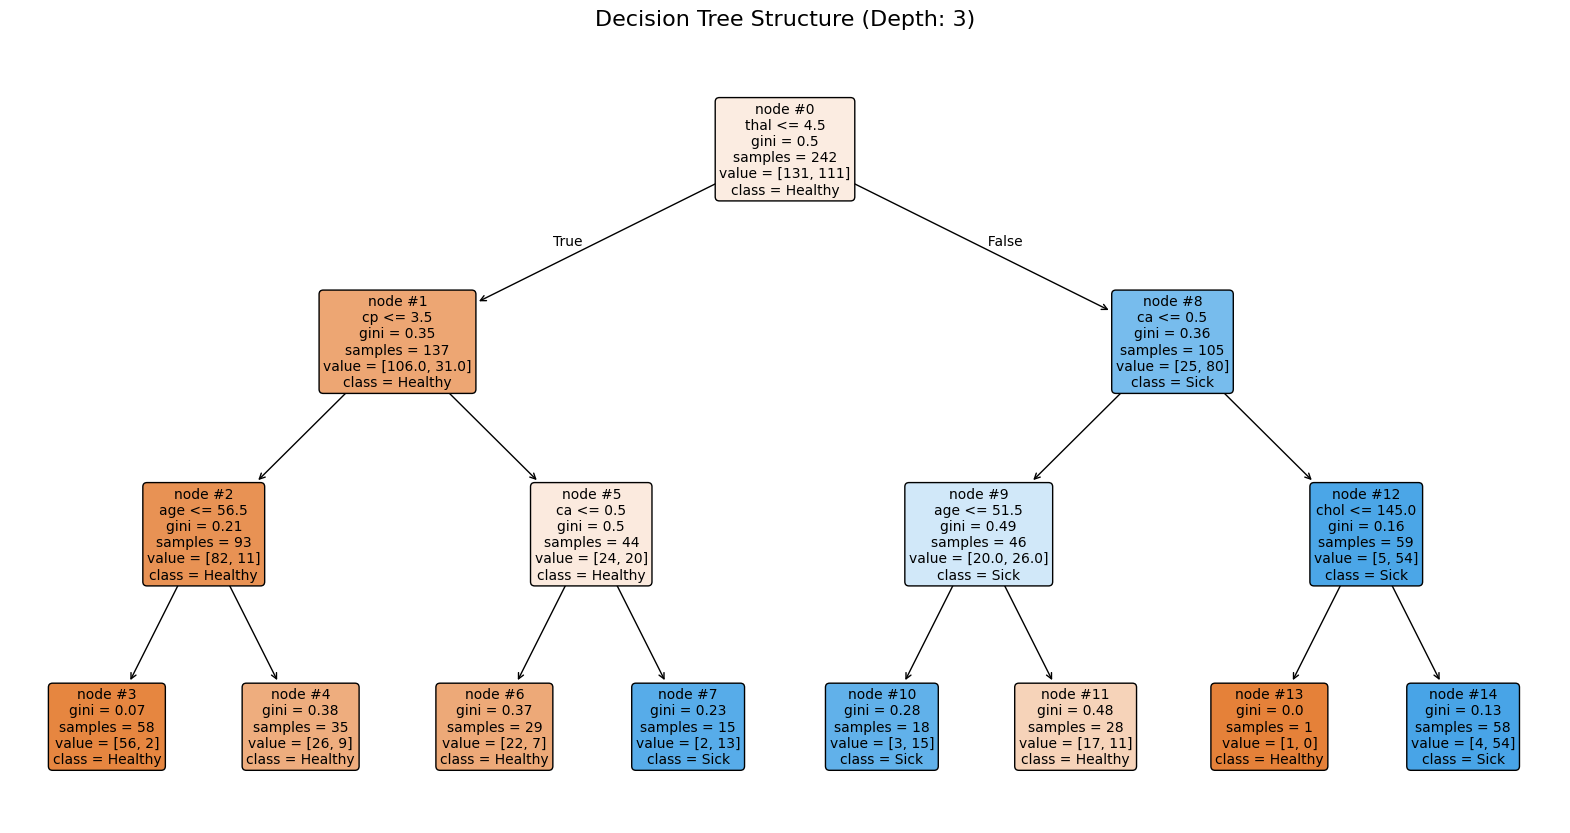

c:\Users\Piotrek\Desktop\projekt_programowanie\Task_2\charts.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


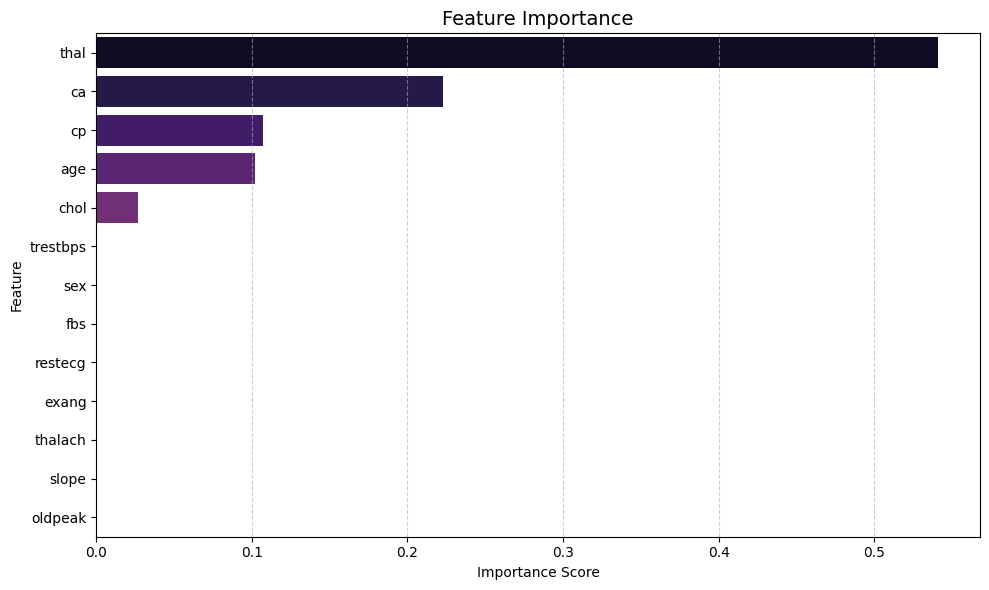

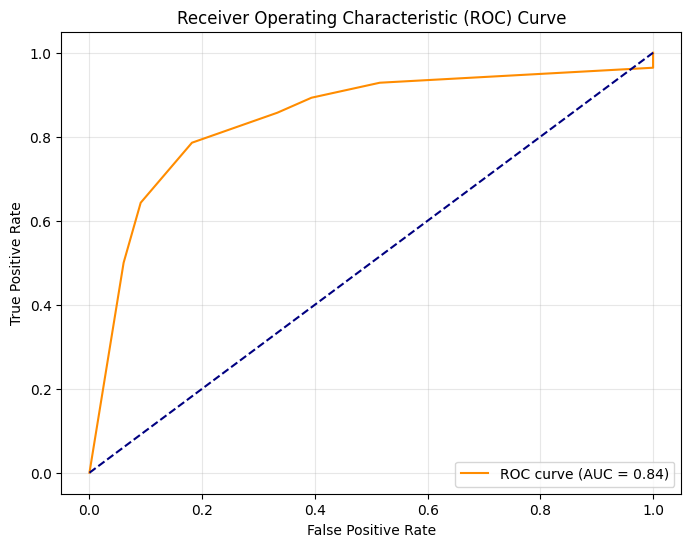

In [14]:
X_train, X_test, y_train, y_test = decision_tree.split_dateset(df_clean, 0.2, 47)
my_tree, y_pred = decision_tree.run_tree_analysis(X_train, X_test, y_train, y_test, max_depth=3, random_state_new=47)
charts.plot_confusion_matrix(y_test, y_pred)
charts.plot_tree_structure(my_tree, X_train.columns)
charts.plot_feature_importance(my_tree, X_train.columns)
charts.plot_roc_curve(my_tree, X_test, y_test)

=== DATA BREAKDOWN SUMMARY ===
Entire collection: 303 
Training set: 242 
Test set (for model testing): 61 

Checking class balance (stratify):
Proportion sick patients in the training set: 45.9%
Proportion sick patients in the test set: 45.9%
--- Training Model (max_depth=4) ---
Model Accuracy: 81.97%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.84      0.82      0.83        33
        Sick       0.79      0.82      0.81        28

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



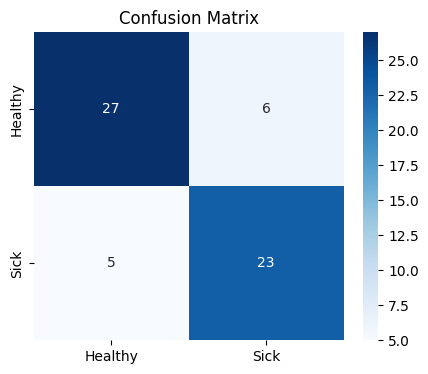

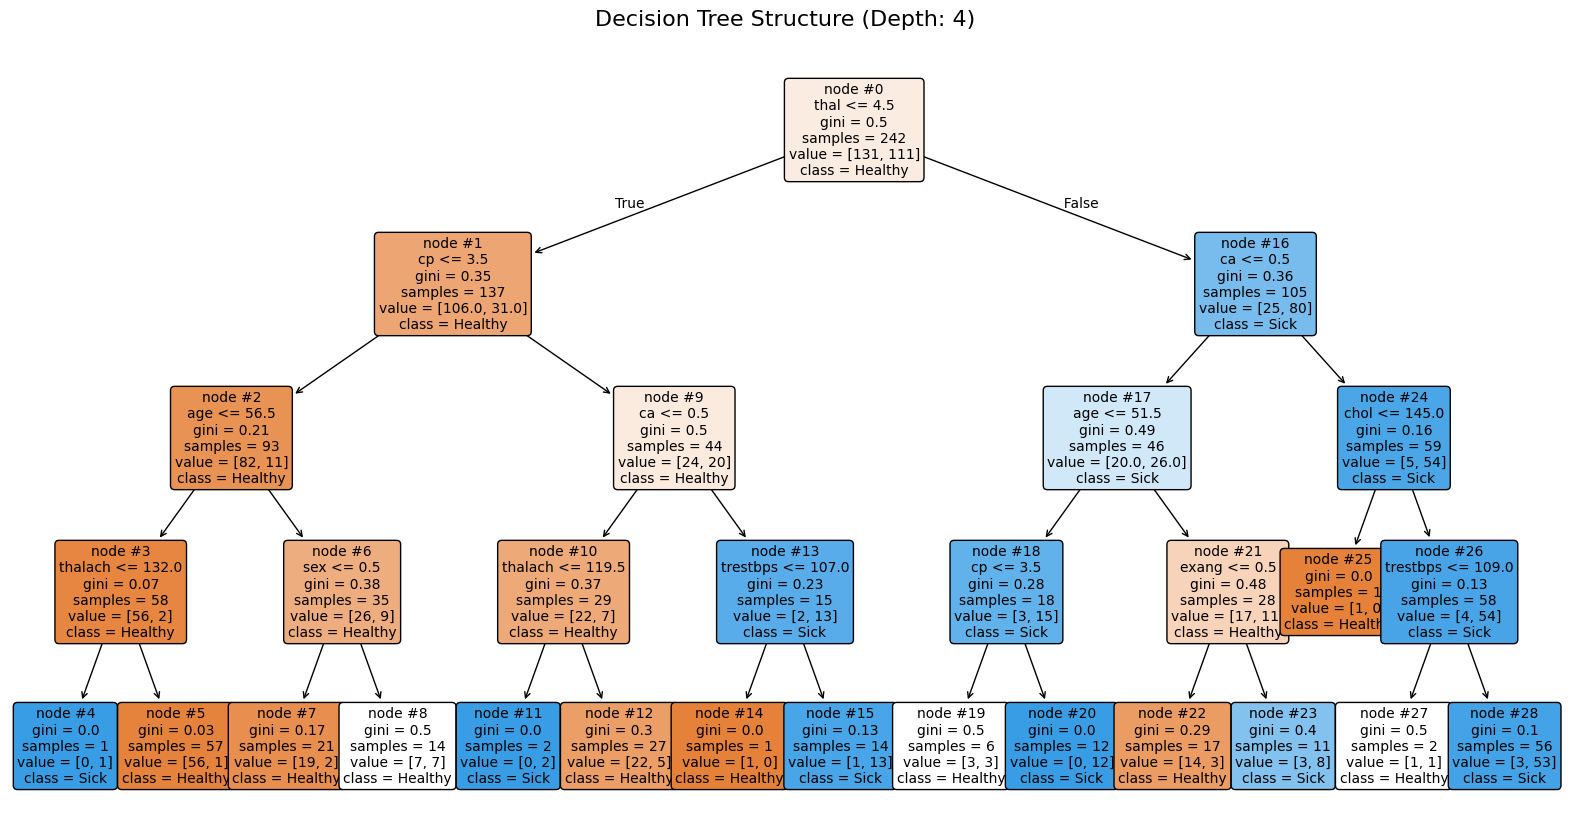

c:\Users\Piotrek\Desktop\projekt_programowanie\Task_2\charts.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


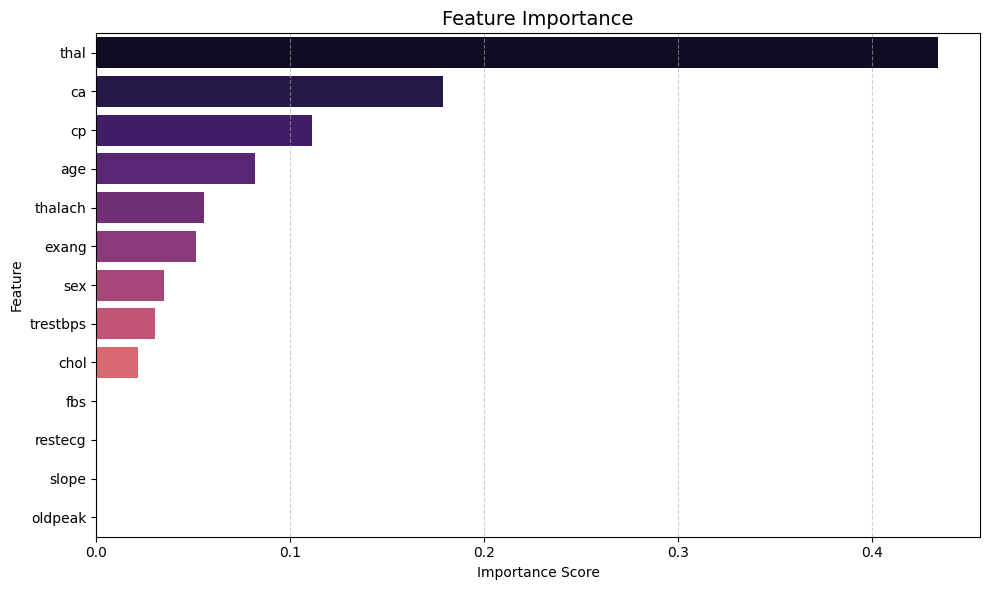

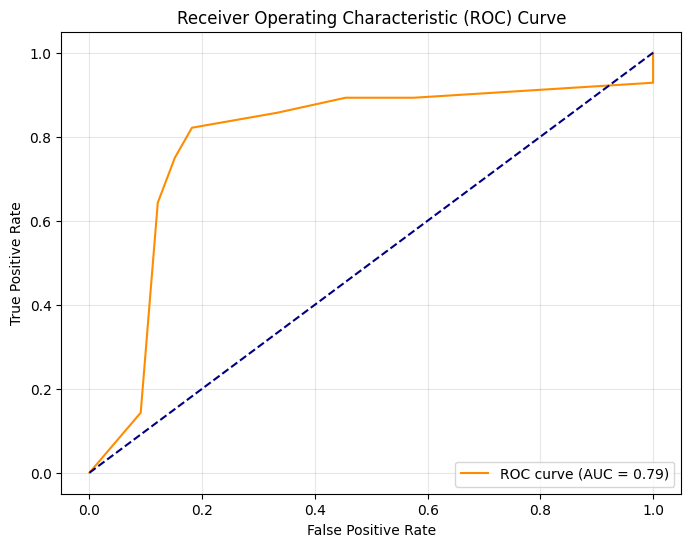

In [15]:
X_train, X_test, y_train, y_test = decision_tree.split_dateset(df_clean, 0.2, 47)
my_tree, y_pred = decision_tree.run_tree_analysis(X_train, X_test, y_train, y_test, max_depth=4, random_state_new=47)
charts.plot_confusion_matrix(y_test, y_pred)
charts.plot_tree_structure(my_tree, X_train.columns)
charts.plot_feature_importance(my_tree, X_train.columns)
charts.plot_roc_curve(my_tree, X_test, y_test)

#### Sprawdzenie depth 3 i 4 na jeszce innych zbiorach

=== DATA BREAKDOWN SUMMARY ===
Entire collection: 303 
Training set: 242 
Test set (for model testing): 61 

Checking class balance (stratify):
Proportion sick patients in the training set: 45.9%
Proportion sick patients in the test set: 45.9%
--- Training Model (max_depth=3) ---
Model Accuracy: 80.33%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.82      0.82      0.82        33
        Sick       0.79      0.79      0.79        28

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



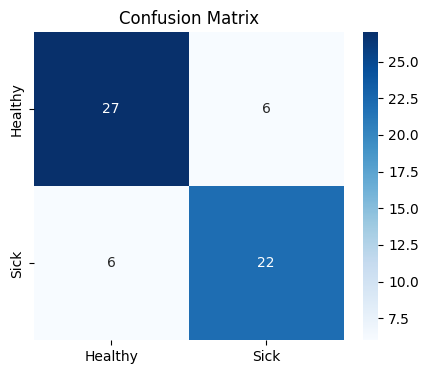

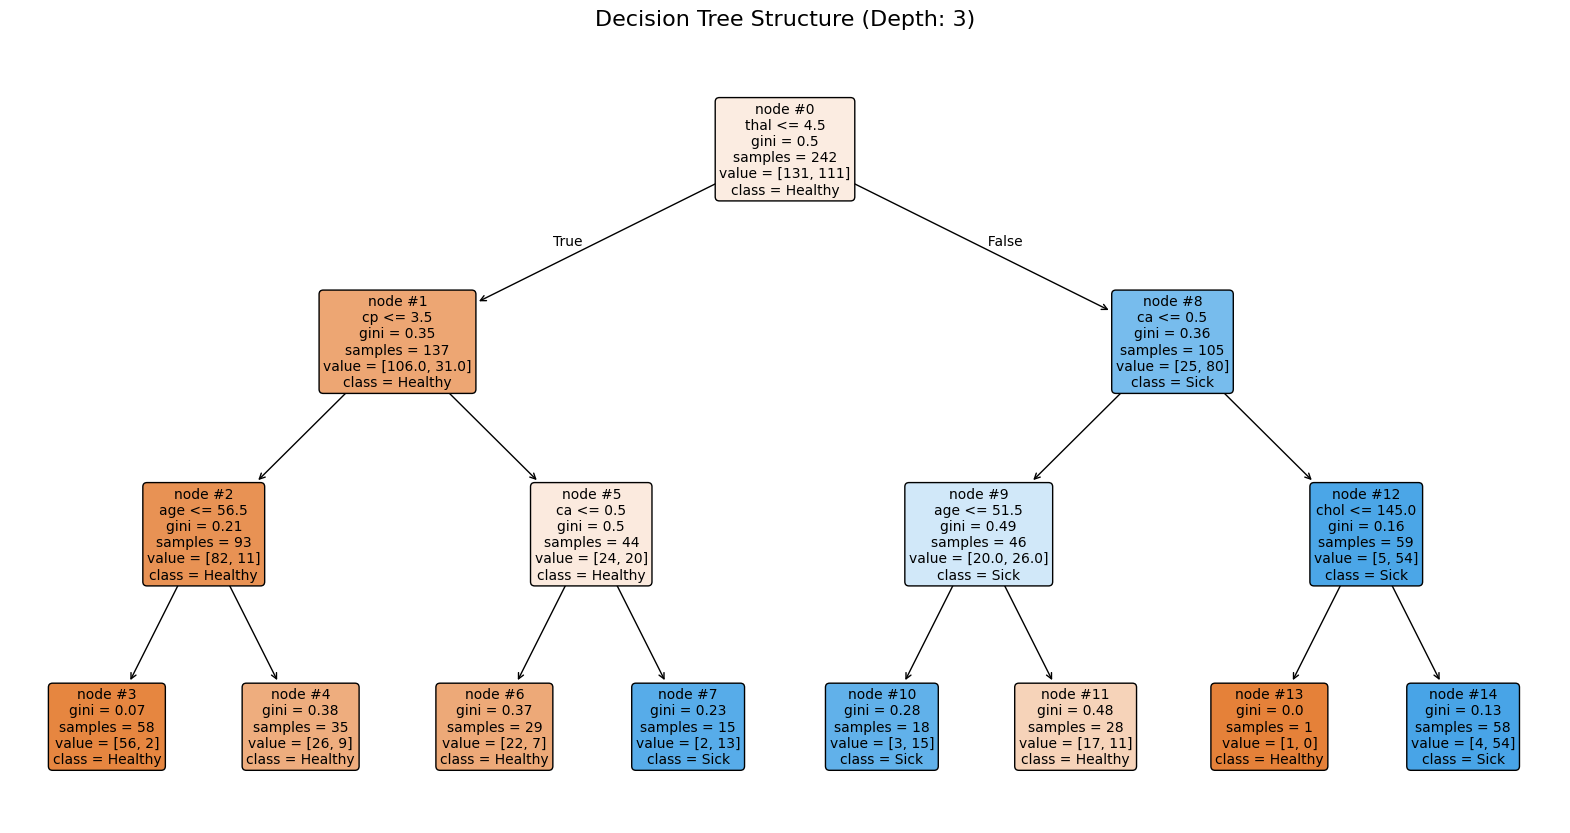

c:\Users\Piotrek\Desktop\projekt_programowanie\Task_2\charts.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


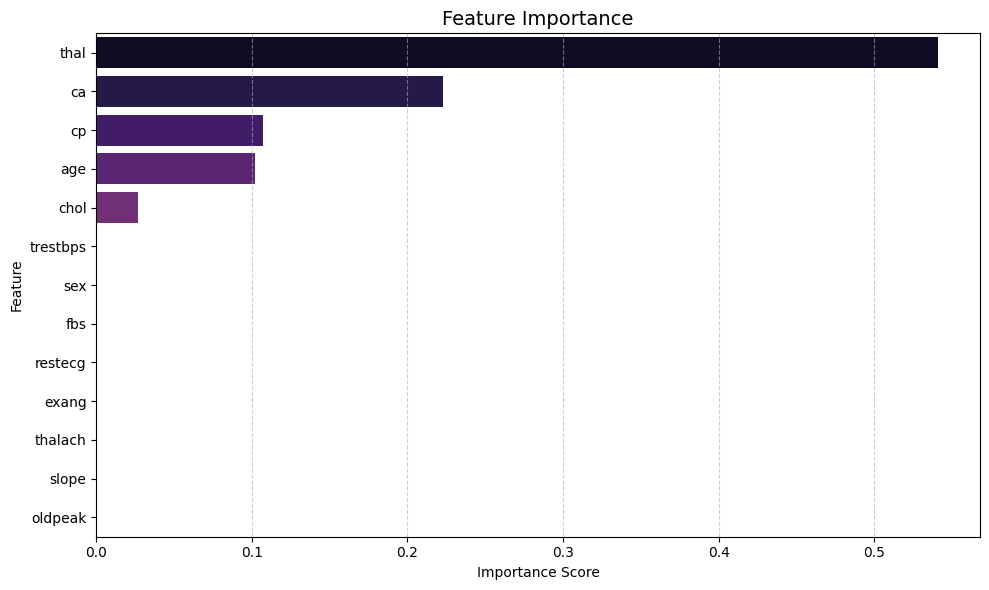

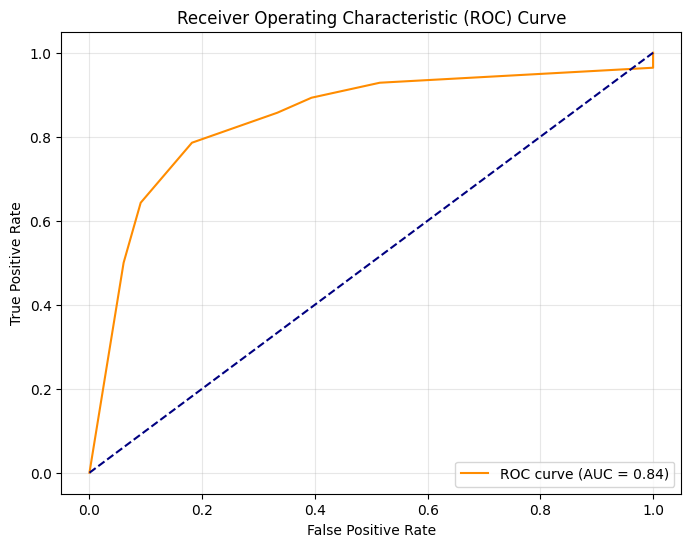

--- Training Model (max_depth=4) ---
Model Accuracy: 81.97%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.84      0.82      0.83        33
        Sick       0.79      0.82      0.81        28

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



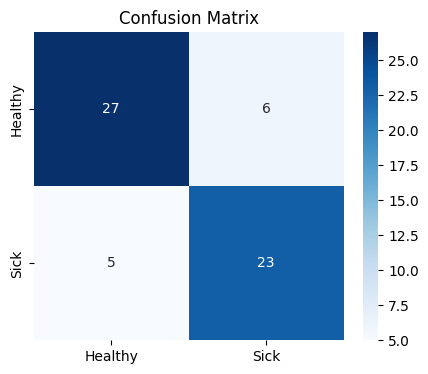

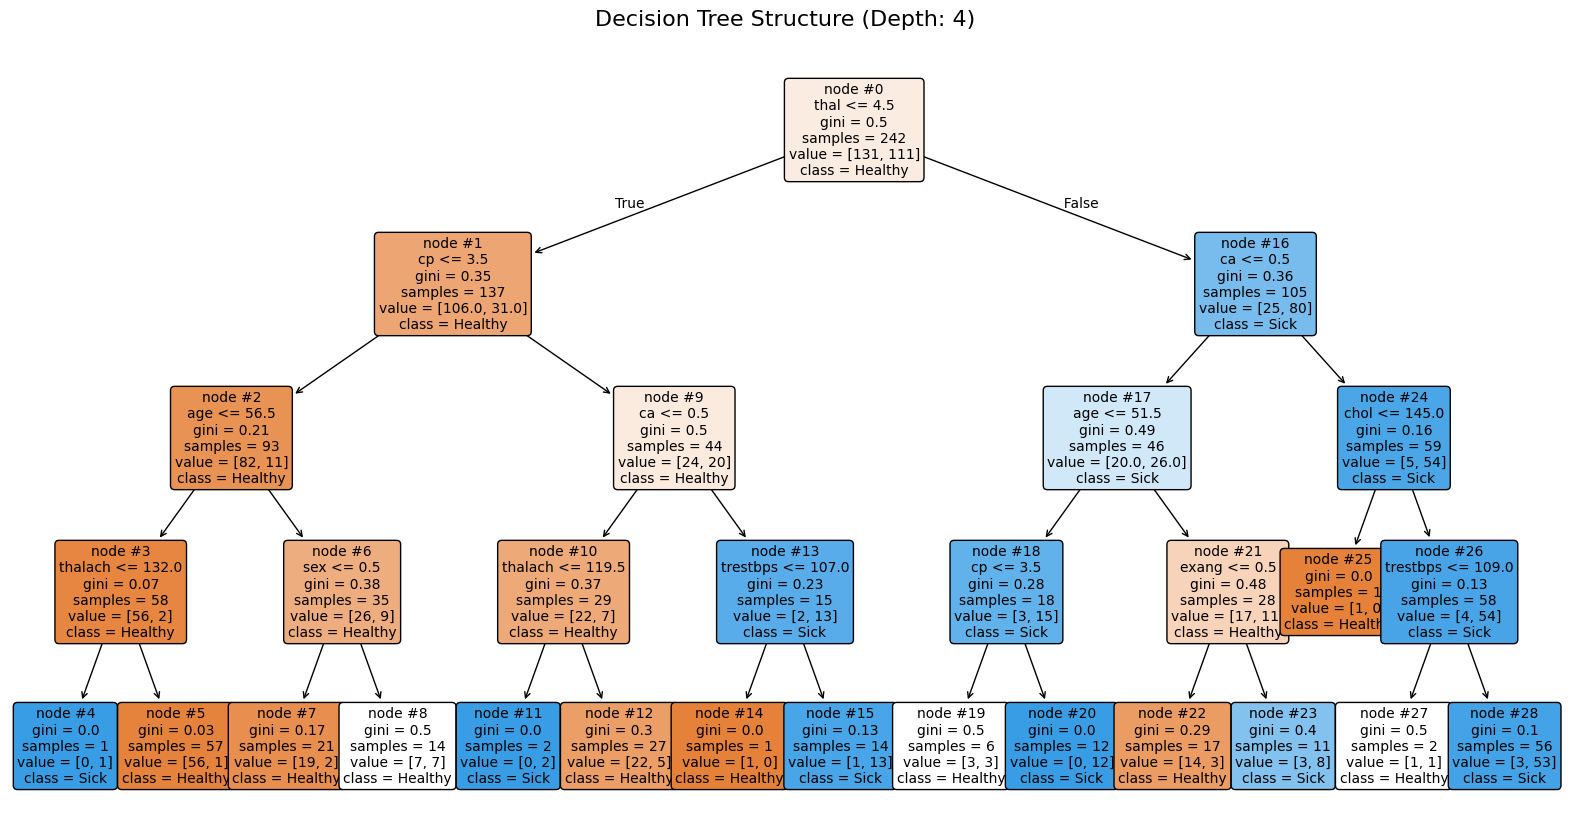

c:\Users\Piotrek\Desktop\projekt_programowanie\Task_2\charts.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


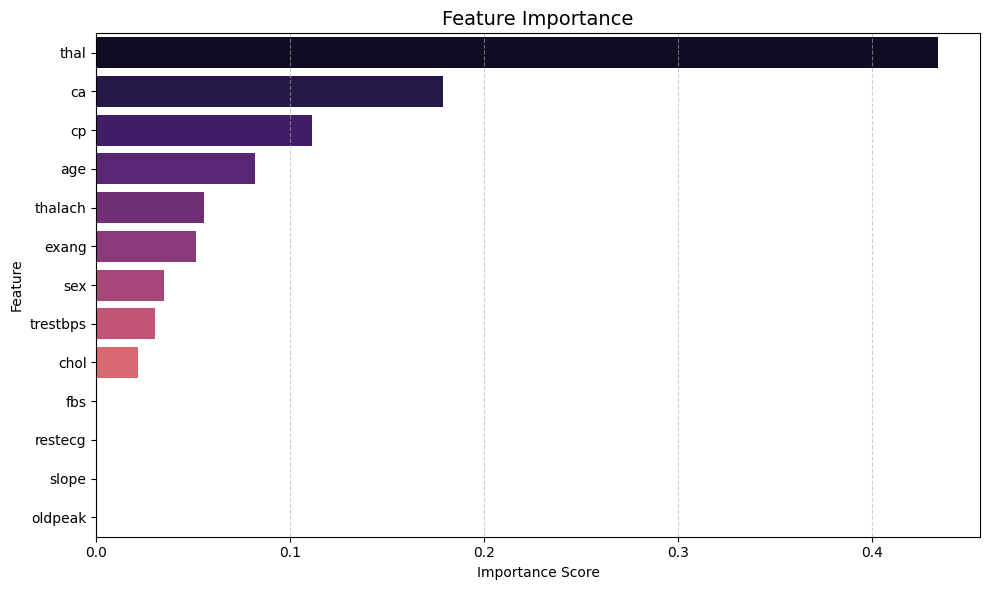

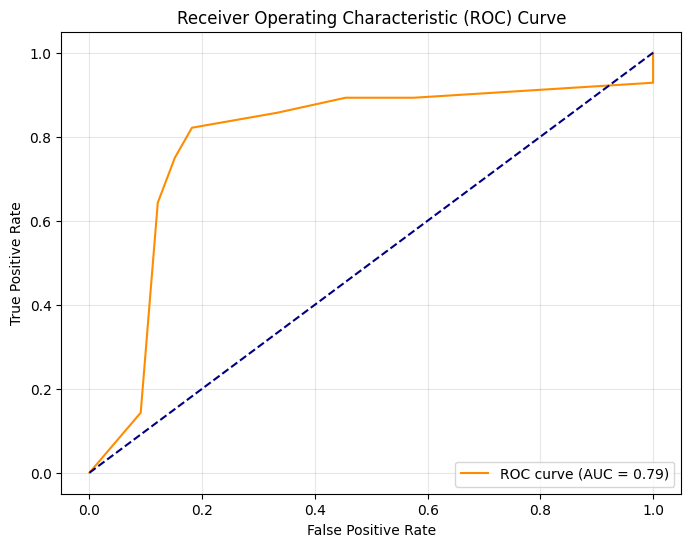

In [16]:
X_train, X_test, y_train, y_test = decision_tree.split_dateset(df_clean, 0.2, 47)
my_tree, y_pred = decision_tree.run_tree_analysis(X_train, X_test, y_train, y_test, max_depth=3, random_state_new=42)
charts.plot_confusion_matrix(y_test, y_pred)
charts.plot_tree_structure(my_tree, X_train.columns)
charts.plot_feature_importance(my_tree, X_train.columns)
charts.plot_roc_curve(my_tree, X_test, y_test)


my_tree, y_pred = decision_tree.run_tree_analysis(X_train, X_test, y_train, y_test, max_depth=4, random_state_new=42)
charts.plot_confusion_matrix(y_test, y_pred)
charts.plot_tree_structure(my_tree, X_train.columns)
charts.plot_feature_importance(my_tree, X_train.columns)
charts.plot_roc_curve(my_tree, X_test, y_test)

#### Wnioski

* Dla różnych random_state model o głębokości 3 osiąga bardzo dobre wyniki, świadczy to o jego stabilności.
* Krótkie drzewo skupia sie na najważniejszych cechach (depth=3 na 6 w trzech wyżej przedstawionych przypadkach). 
* Głębokie drzewo (np. depth=8) staje się "czarną skrzynką" której ciężko prześledzić kroki.
* Głębokie drzewa zaczynają "uczyć się na pamięć" błędów w danych lub nietypowych, jednostkowych przypadków, co psuje wynik końcowy (overfitting). Przykład: Jestem chory bo jestem mężczyzną który ma 27 lat duży cholesterol, ból w klatce, i mieszkam na podlasiu i mam 3 siostry i czerwone buty.
* Analiza wykazała, że przy zwiększaniu głębokości powyżej 3-4, model traci na czułości (Recall) oraz stabilności (AUC).

#### Podsumowanie sprawozdania:
* Zbiór ma 303 wiersze i ma 13 "Features" (kolumn) + jedną kolumne "target" posiadającą dane odnośnie choroby.
* Z obserwacji wynikło, że kolumny "ca" i "thal" posiadają braki w wartościach (6 wierszy)
* Uzupełniono braki wartości algorytmem knn 
* Znormalizowano kolumne target (0 zdrowy, 1 chory)
* Wykonano wstępną analize z której wynikło, że "cp", "thal", "age", "sex", "ca", "exang" najwięcej mówią o chorobie.
* Podzielono zbiór na 80% do treningu i 20% do testu
* Wykonano drzewa decyzyjne oraz wykresy które potwierdziły, że "cp", "thal", "age", "sex", "ca", "exang" mają najwiejszą wartość w stosunku do podejmowania decyzji
* Stwierdzono, że drzewa z depth=3 osiągają bardzo dobre wyniki, i są stabilne nawet w innych zbiorach. 
